# Store Sales — Time Series Forecasting
## Part 1 · Exploratory Data Analysis

**Business problem.** Corporación Favorita, a large Ecuadorian grocery retailer, needs
daily unit-sales forecasts per product family per store. Over-forecast and perishable
stock is written off; under-forecast and shelves go empty and revenue walks out the door.

**Modelling problem.** Forecast `sales` for every `(date, store_nbr, family)` triple in
the 16 days that follow the end of the training window.

**Metric — RMSLE.**

$$\mathrm{RMSLE} \;=\; \sqrt{\frac{1}{n}\sum_{i=1}^{n}\Big(\log(1+\hat{y}_i) - \log(1+y_i)\Big)^{2}}$$

Two consequences drive every decision downstream:

1. The error is measured on `log1p(sales)`, so it penalises **relative** error. Missing a
   series that sells 5 units/day by 5 units costs as much as missing a 5,000-unit series
   by 5,000. Low-volume store×family pairs matter just as much as `GROCERY I`.
2. It is **asymmetric in raw space**: under-forecasting is punished harder than
   over-forecasting by the same absolute amount. Modelling in log space is the natural fit.

### What this notebook covers

| § | Question |
|---|---|
| 1 | What exactly is in each file, and is the panel complete? |
| 2 | How is the target distributed, and what does RMSLE do to it? |
| 3 | Trend and the three seasonal cycles (annual, weekly, monthly) |
| 4 | Store heterogeneity — openings, type, cluster, geography |
| 5 | Product families — concentration and zero-inflation |
| 6 | `onpromotion` — coverage and lift |
| 7 | Oil price — is the macro signal usable? |
| 8 | Holidays — building a correct calendar from a messy file |
| 9 | The April 2016 earthquake |
| 10 | Transactions — useful, but a leakage trap |
| 11 | Autocorrelation and lag structure |
| 12 | **Effect sizing at p90** — re-measuring §7–§9 with series and weekday held fixed |
| 13 | **Holidays are not one thing** — per-holiday effects, and an audit of the forecast window |
| 14 | A validation split that mirrors the test set, plus naive RMSLE baselines |
| 15 | Findings and what they imply for modelling |

> This notebook refines its own estimates twice, and both revisions matter.
> §1–§11 quote **ratios of means**; §12 shows several of those are wrong once series
> composition and weekday are held fixed; §13 shows §12's own holiday numbers are still
> inflated because they do not control for **season**. The numbers carried into §15 and into
> the modelling notebook are §13's.

---
## 0 · Setup

Chart styling is defined once here: a validated categorical palette (fixed slot order,
never cycled), a single-hue blue ramp for magnitude, and recessive grid/axis ink so the
data marks carry the contrast.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# --- Categorical slots: fixed order, assigned by entity, never by rank ------------
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
       "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

# --- Single-hue ramp for magnitude (sequential encoding) --------------------------
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)

# --- Diverging pair (two hues + neutral midpoint) ---------------------------------
DIV = LinearSegmentedColormap.from_list("div_br", ["#184f95", "#9ec5f4", "#f0efec",
                                                   "#f0a3a2", "#c22a29"])

# --- Chrome & ink ------------------------------------------------------------------
SURFACE, INK, SECOND, MUTED = "#ffffff", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "figure.autolayout": False,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 9.5,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.titlepad": 10,
    "axes.labelcolor": SECOND, "axes.labelsize": 9.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "lines.linewidth": 2, "lines.markersize": 5, "lines.solid_capstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9,
    "axes.prop_cycle": plt.cycler(color=CAT),
})

def finish(ax, title=None, sub=None, xlabel=None, ylabel=None, ygrid=True, xgrid=False):
    """Apply the shared chart anatomy: left-aligned title, one subtitle line, recessive grid."""
    if title:
        # Reserve room above the axes for the subtitle line, so the two never collide.
        ax.set_title(title, loc="left", pad=24 if sub else 10)
    if sub:
        ax.text(0, 1.015, sub, transform=ax.transAxes, color=MUTED, fontsize=8.5,
                va="bottom", ha="left")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.grid(ygrid, axis="y"); ax.grid(xgrid, axis="x")
    return ax

def thousands(x, _=None):
    """Axis tick formatter: 1_500_000 -> '1.5M'."""
    for div, suf in ((1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(x) >= div:
            return f"{x/div:,.1f}{suf}".replace(".0", "")
    return f"{x:,.0f}"

print("Style loaded.")

Style loaded.


In [2]:
# Resolve the data directory whether the notebook runs from ./ or ./notebooks/
DATA = next(p for p in (Path("data"), Path("../data"), Path("../../data")) if p.exists())
print("Data directory:", DATA.resolve())

DTYPES = {"store_nbr": "int8", "family": "category", "onpromotion": "int32", "sales": "float32"}

train  = pd.read_csv(DATA / "train.csv",  parse_dates=["date"], dtype=DTYPES)
test   = pd.read_csv(DATA / "test.csv",   parse_dates=["date"], dtype=DTYPES)
stores = pd.read_csv(DATA / "stores.csv", dtype={"store_nbr": "int8"})
oil    = pd.read_csv(DATA / "oil.csv",    parse_dates=["date"])
hol    = pd.read_csv(DATA / "holidays_events.csv", parse_dates=["date"])
txn    = pd.read_csv(DATA / "transactions.csv",    parse_dates=["date"],
                     dtype={"store_nbr": "int8", "transactions": "int32"})
sub    = pd.read_csv(DATA / "sample_submission.csv")

for name, df in [("train", train), ("test", test), ("stores", stores), ("oil", oil),
                 ("holidays_events", hol), ("transactions", txn), ("sample_submission", sub)]:
    print(f"{name:<20} {df.shape[0]:>9,} rows x {df.shape[1]} cols"
          f"   {df.memory_usage(deep=True).sum()/1e6:>7.1f} MB")

Data directory: G:\Meu Drive\_Portifolio\Store Sales - Time Series Forecasting\data


train                3,000,888 rows x 6 cols      78.0 MB
test                    28,512 rows x 5 cols       0.6 MB
stores                      54 rows x 5 cols       0.0 MB
oil                      1,218 rows x 2 cols       0.0 MB
holidays_events            350 rows x 6 cols       0.1 MB
transactions            83,488 rows x 3 cols       1.1 MB
sample_submission       28,512 rows x 2 cols       0.5 MB


---
## 1 · Dataset overview

In [3]:
def profile(df, name):
    row = {"file": name, "rows": len(df), "cols": df.shape[1],
           "nulls": int(df.isna().sum().sum())}
    if "date" in df:
        row["date_min"] = df["date"].min().date()
        row["date_max"] = df["date"].max().date()
        row["n_dates"] = df["date"].nunique()
    return row

pd.DataFrame([profile(train, "train"), profile(test, "test"), profile(txn, "transactions"),
              profile(oil, "oil"), profile(hol, "holidays_events"),
              profile(stores, "stores"), profile(sub, "sample_submission")]).fillna("—")

,file,rows,cols,nulls,date_min,date_max,n_dates
0,train,3000888,6,0,2013-01-01,2017-08-15,"1,684.000"
1,test,28512,5,0,2017-08-16,2017-08-31,16.000
2,transactions,83488,3,0,2013-01-01,2017-08-15,"1,682.000"
3,oil,1218,2,43,2013-01-01,2017-08-31,"1,218.000"
4,holidays_events,350,6,0,2012-03-02,2017-12-26,312.000
5,stores,54,5,0,—,—,—
6,sample_submission,28512,2,0,—,—,—


In [4]:
n_store, n_fam = train.store_nbr.nunique(), train.family.nunique()
n_dates_tr, n_dates_te = train.date.nunique(), test.date.nunique()

print(f"stores                : {n_store}")
print(f"product families      : {n_fam}")
print(f"series (store x family): {n_store * n_fam:,}")
print()
print(f"train window : {train.date.min():%Y-%m-%d} -> {train.date.max():%Y-%m-%d}"
      f"  ({n_dates_tr} distinct dates)")
print(f"test  window : {test.date.min():%Y-%m-%d} -> {test.date.max():%Y-%m-%d}"
      f"  ({n_dates_te} distinct dates)")
print()
print(f"train rows        : {len(train):>10,}   perfect grid = {n_dates_tr*n_store*n_fam:>10,}"
      f"   -> {'COMPLETE' if len(train)==n_dates_tr*n_store*n_fam else 'RAGGED'}")
print(f"test  rows        : {len(test):>10,}   perfect grid = {n_dates_te*n_store*n_fam:>10,}"
      f"   -> {'COMPLETE' if len(test)==n_dates_te*n_store*n_fam else 'RAGGED'}")
print(f"submission rows   : {len(sub):>10,}   ids match test = {sub.id.equals(test.id)}")

stores                : 54
product families      : 33
series (store x family): 1,782

train window : 2013-01-01 -> 2017-08-15  (1684 distinct dates)
test  window : 2017-08-16 -> 2017-08-31  (16 distinct dates)

train rows        :  3,000,888   perfect grid =  3,000,888   -> COMPLETE
test  rows        :     28,512   perfect grid =     28,512   -> COMPLETE
submission rows   :     28,512   ids match test = True


In [5]:
# The grid is complete for the dates present -- but are all calendar dates present?
calendar = pd.date_range(train.date.min(), train.date.max(), freq="D")
missing_dates = calendar.difference(pd.DatetimeIndex(train.date.unique()))

print(f"Calendar days spanned : {len(calendar)}")
print(f"Days present in train : {n_dates_tr}")
print(f"Days absent           : {len(missing_dates)}")
for d in missing_dates:
    print(f"   {d:%Y-%m-%d}  ({d:%A})")

Calendar days spanned : 1688
Days present in train : 1684
Days absent           : 4
   2013-12-25  (Wednesday)
   2014-12-25  (Thursday)
   2015-12-25  (Friday)
   2016-12-25  (Sunday)


**Read.** The panel is a *complete* rectangle — 54 stores × 33 families × every date
present — with no nulls anywhere in `train`. That is unusually clean and it matters: no
imputation of missing rows is needed, and the test set is the same rectangle extended
16 days forward.

The four absent dates are all **25 December**. Every store closes on Christmas Day; those
rows were dropped rather than written as zeros. When building lag features on a continuous
daily index, reindex and decide explicitly what Christmas should be (a zero row is the
honest value). The test window (16–31 August) contains no Christmas, so this affects
feature construction, not the prediction target.

---
## 2 · The target

In [6]:
s = train.sales
print(s.describe().to_string())
print()
print(f"zeros            : {(s == 0).mean():.1%} of all rows")
print(f"negative values  : {(s < 0).sum()}")
print(f"non-integer sales: {(s % 1 != 0).mean():.1%}  (products sold by weight)")
print(f"max              : {s.max():,.0f}")
print()
print("Upper tail (quantiles):")
print(s.quantile([.5, .75, .9, .95, .99, .999, 1]).to_string())

count   3,000,888.000
mean          357.776
std         1,101.998
min             0.000
25%             0.000
50%            11.000
75%           195.847
max       124,717.000

zeros            : 31.3% of all rows
negative values  : 0


non-integer sales: 15.4%  (products sold by weight)
max              : 124,717

Upper tail (quantiles):


0.500        11.000
0.750       195.847
0.900       867.000
0.950     1,965.000
0.990     5,507.000
0.999    12,076.226
1.000   124,717.000


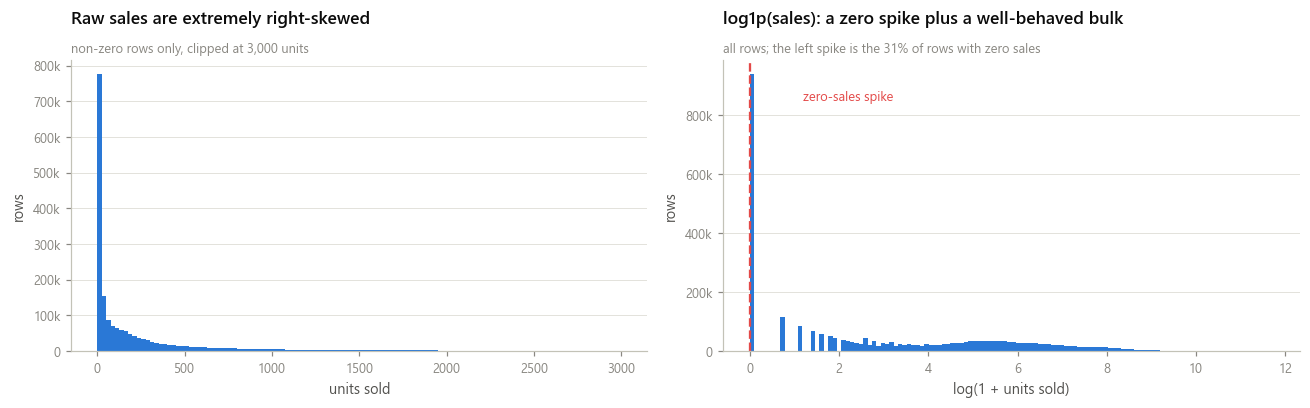

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

nz = s[s > 0]
axes[0].hist(nz, bins=120, range=(0, 3000), color=CAT[0], edgecolor="none")
finish(axes[0], "Raw sales are extremely right-skewed",
       "non-zero rows only, clipped at 3,000 units", "units sold", "rows")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(thousands))

axes[1].hist(np.log1p(s), bins=120, color=CAT[0], edgecolor="none")
finish(axes[1], "log1p(sales): a zero spike plus a well-behaved bulk",
       "all rows; the left spike is the 31% of rows with zero sales",
       "log(1 + units sold)", "rows")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(thousands))
axes[1].axvline(0, color=CAT[7], lw=1.5, ls="--")
axes[1].annotate("zero-sales spike", xy=(0, 0), xytext=(1.2, 0.86),
                 textcoords=("data", "axes fraction"), color=CAT[7], fontsize=8.5)

fig.tight_layout(); plt.show()

**Read.** Raw `sales` spans 0 → 124,717 with a median of 11 — five orders of magnitude, and
a 99th percentile (5,507) that is still only 4% of the maximum. Under `log1p` the
distribution becomes tractable: a point mass at zero, a comb of small integer counts, then
a broad, roughly symmetric bulk. Since RMSLE *is* RMSE on `log1p`, the modelling target
should be `log1p(sales)`, with `expm1` and a clip at 0 on the way back out.

15% of values are non-integer — those are the families sold by weight, not data errors.

31% of rows are exactly zero. That is not noise — it is mostly structural (a store does not
stock that family at all), which §5 separates from genuine stock-outs.

---
## 3 · Time structure

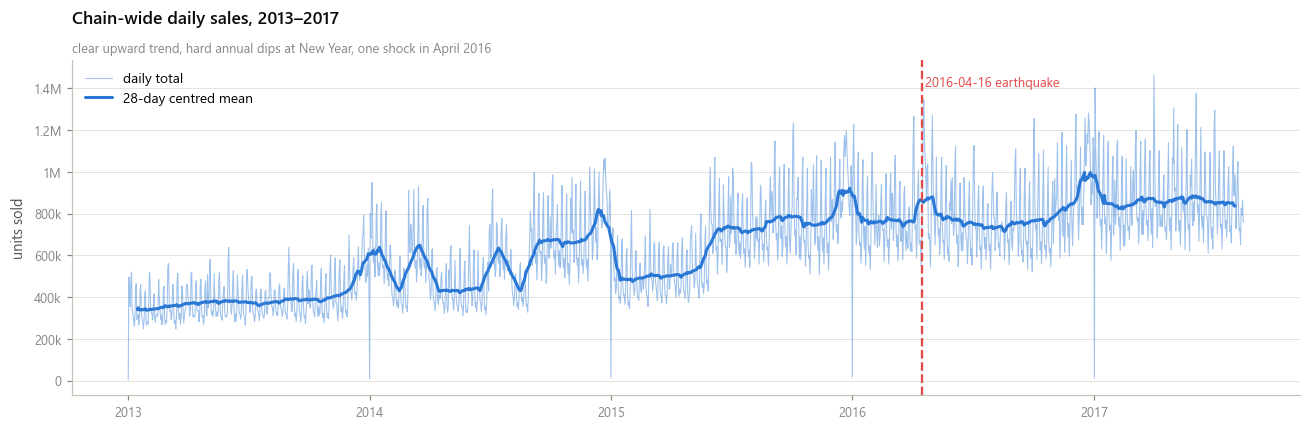

In [8]:
daily = train.groupby("date", as_index=False)["sales"].sum()
daily["roll28"] = daily.sales.rolling(28, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.date, daily.sales, color=CAT[0], lw=0.7, alpha=0.45, label="daily total")
ax.plot(daily.date, daily.roll28, color=CAT[0], lw=2, label="28-day centred mean")
ax.axvline(pd.Timestamp("2016-04-16"), color=CAT[7], lw=1.5, ls="--")
ax.annotate("2016-04-16 earthquake", xy=(pd.Timestamp("2016-04-20"), 0.92),
            xycoords=("data", "axes fraction"), color=CAT[7], fontsize=8.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "Chain-wide daily sales, 2013–2017",
       "clear upward trend, hard annual dips at New Year, one shock in April 2016",
       ylabel="units sold")
ax.legend(loc="upper left")
fig.tight_layout(); plt.show()

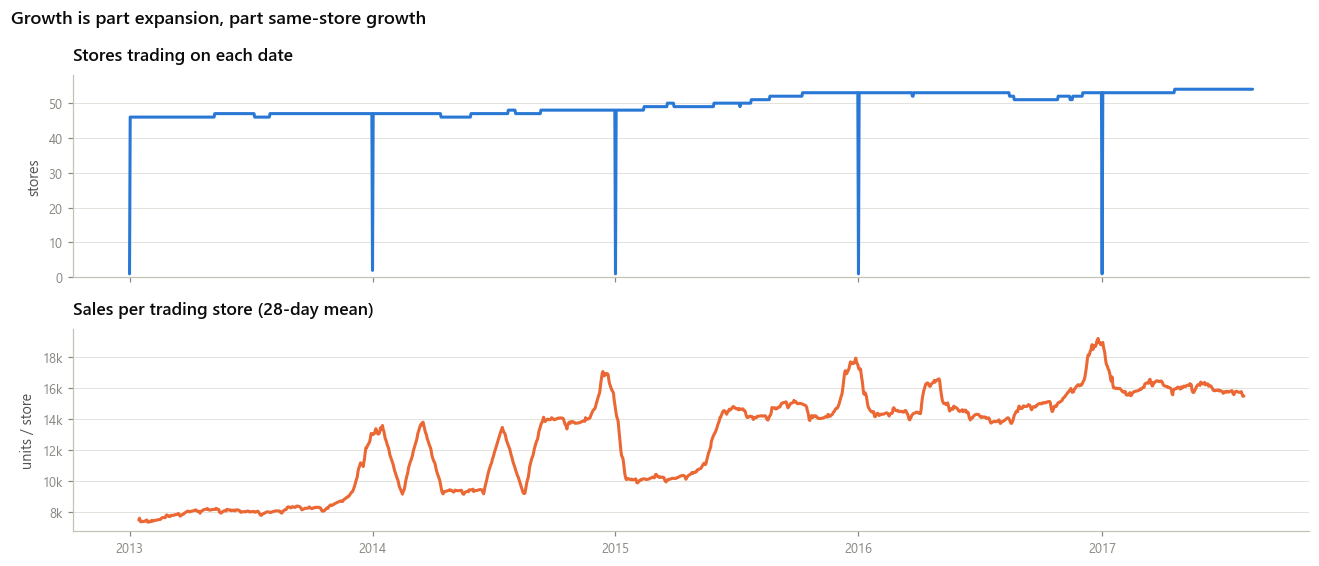

In [9]:
# Where does the trend come from -- more stores, or more sales per store?
active = train[train.sales > 0].groupby("date").store_nbr.nunique()
per_store = daily.set_index("date").sales / active

fig, axes = plt.subplots(2, 1, figsize=(12, 5.2), sharex=True)

axes[0].plot(active.index, active.values, color=CAT[0])
axes[0].set_ylim(0, 58)
finish(axes[0], "Stores trading on each date", ylabel="stores")

axes[1].plot(per_store.index, per_store.rolling(28, center=True).mean(), color=CAT[1])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(axes[1], "Sales per trading store (28-day mean)", ylabel="units / store")

fig.suptitle("Growth is part expansion, part same-store growth", x=0.005, ha="left",
             fontsize=12, fontweight="semibold", color=INK)
fig.tight_layout(); plt.show()

Two separate charts rather than one dual-axis chart: the two measures share a time axis but
not a scale, and overlaying them on twin y-axes would invite a false reading of where the
lines cross.

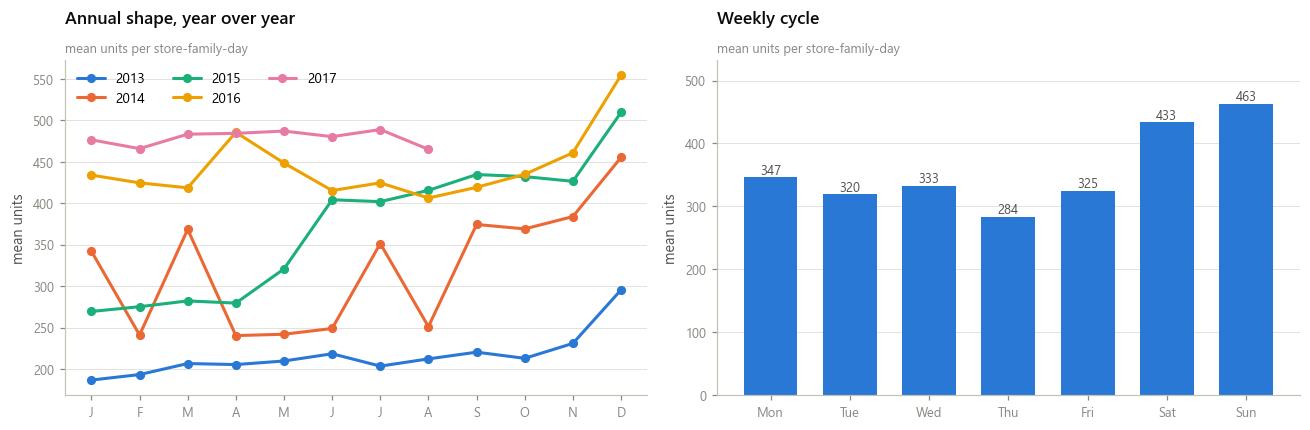

Weekend uplift: Sunday is +63% vs Thursday (the weekly trough).


In [10]:
d = train[["date", "sales"]].copy()
d["year"], d["month"] = d.date.dt.year, d.date.dt.month
monthly = d.groupby(["year", "month"]).sales.mean().unstack(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, yr in enumerate(monthly.columns):
    axes[0].plot(monthly.index, monthly[yr], color=CAT[i], marker="o", label=str(yr))
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(list("JFMAMJJASOND"))
finish(axes[0], "Annual shape, year over year",
       "mean units per store-family-day", ylabel="mean units")
axes[0].legend(loc="upper left", ncol=3)

dow = train.groupby(train.date.dt.dayofweek).sales.mean()
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
bars = axes[1].bar(names, dow.values, color=CAT[0], width=0.68)
for b, v in zip(bars, dow.values):
    axes[1].text(b.get_x() + b.get_width()/2, v, f"{v:,.0f}", ha="center", va="bottom",
                 fontsize=8.5, color=SECOND)
axes[1].set_ylim(0, dow.max() * 1.15)
finish(axes[1], "Weekly cycle", "mean units per store-family-day", ylabel="mean units")

fig.tight_layout(); plt.show()

print(f"Weekend uplift: Sunday is {dow[6]/dow[3] - 1:+.0%} vs Thursday (the weekly trough).")

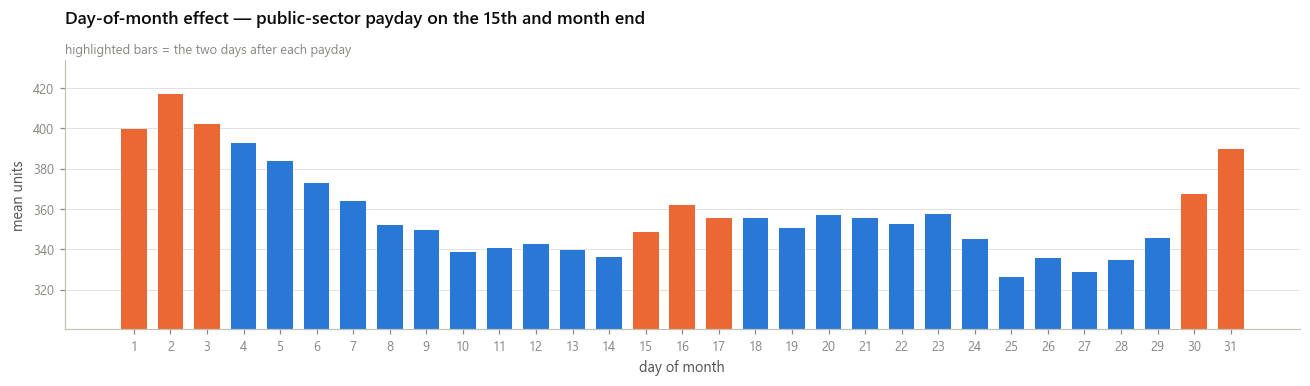

Payday windows run +8.5% above other days of the month.


In [11]:
dom = train.groupby(train.date.dt.day).sales.mean()

fig, ax = plt.subplots(figsize=(12, 3.6))
colors = [CAT[1] if day in (1, 2, 3, 15, 16, 17, 30, 31) else CAT[0] for day in dom.index]
ax.bar(dom.index, dom.values, color=colors, width=0.7)
ax.set_xticks(range(1, 32))
ax.set_ylim(dom.min() * 0.92, dom.max() * 1.04)
finish(ax, "Day-of-month effect — public-sector payday on the 15th and month end",
       "highlighted bars = the two days after each payday", "day of month", "mean units")
fig.tight_layout(); plt.show()

payday_win = dom.reindex([15, 16, 17, 30, 31, 1, 2, 3]).mean()
other = dom.drop([15, 16, 17, 30, 31, 1, 2, 3]).mean()
print(f"Payday windows run {payday_win/other - 1:+.1%} above other days of the month.")

**Read — three cycles stack on top of the trend.**

* **Annual.** Sales fall off a cliff on 1 January and climb into December. The August test
  window sits on a flat, unexceptional part of the curve, which helps.
* **Weekly.** Saturday and Sunday are the peaks, Thursday the trough — roughly a 60%
  swing. Day-of-week is the single strongest calendar feature.
* **Monthly.** The public-sector payday shows up clearly: the 15th–17th and 30th–3rd run
  about 8.5% above the rest of the month. The first three days are the strongest of all,
  consistent with the month-end wage landing and being spent immediately.

---
## 4 · Stores

In [12]:
first_sale = train[train.sales > 0].groupby("store_nbr").date.min()
late = first_sale[first_sale > train.date.min() + pd.Timedelta(days=7)].sort_values()

print(f"{len(late)} of {n_store} stores have no sales at the start of the panel:\n")
opened = late.to_frame("first_sale")
opened["days_of_history"] = (train.date.max() - opened.first_sale).dt.days
opened.join(stores.set_index("store_nbr")[["city", "type", "cluster"]])

8 of 54 stores have no sales at the start of the panel:



,first_sale,days_of_history,city,type,cluster
store_nbr,,,,,
36,2013-05-09,1559,Libertad,E,10
53,2014-05-29,1174,Manta,D,13
20,2015-02-13,914,Quito,B,6
29,2015-03-20,879,Guayaquil,E,10
21,2015-07-24,753,Santo Domingo,B,6
42,2015-08-21,725,Cuenca,D,2
22,2015-10-09,676,Puyo,C,7
52,2017-04-20,117,Manta,A,11


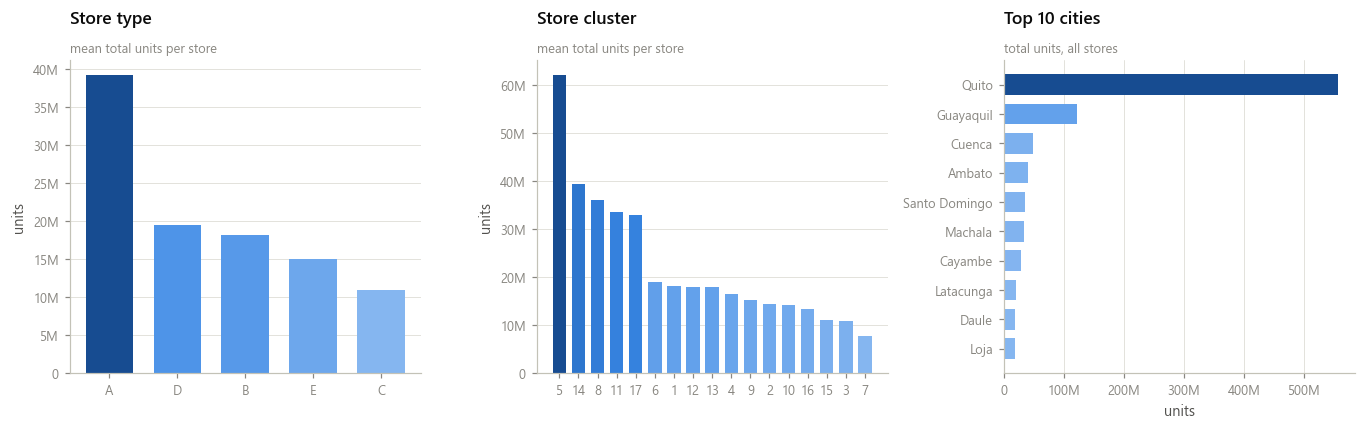

      stores  cities  clusters
type                          
A          9       4         4
B          8       6         3
C         15      12         4
D         18      10         7
E          4       3         1

Quito + Guayaquil hold 26 of 54 stores across 22 cities and 16 states.


In [13]:
sales_by_store = (train.groupby("store_nbr").sales.sum()
                  .to_frame("total").join(stores.set_index("store_nbr")))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4))

for ax, key, title in [(axes[0], "type", "Store type"),
                       (axes[1], "cluster", "Store cluster")]:
    g = sales_by_store.groupby(key).total.mean().sort_values(ascending=False)
    norm = (g - g.min()) / (g.max() - g.min())
    ax.bar([str(i) for i in g.index], g.values, color=SEQ(0.25 + 0.6 * norm.values), width=0.7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
    finish(ax, title, "mean total units per store", ylabel="units")

city = sales_by_store.groupby("city").total.sum().sort_values().tail(10)
norm = (city - city.min()) / (city.max() - city.min())
axes[2].barh([c[:14] for c in city.index], city.values, color=SEQ(0.25 + 0.6 * norm.values),
             height=0.7)
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(axes[2], "Top 10 cities", "total units, all stores", xlabel="units",
       ygrid=False, xgrid=True)

fig.tight_layout(); plt.show()

print(stores.groupby("type").agg(stores=("store_nbr", "size"),
                                 cities=("city", "nunique"),
                                 clusters=("cluster", "nunique")).to_string())
print(f"\nQuito + Guayaquil hold {stores.city.isin(['Quito','Guayaquil']).sum()} of "
      f"{len(stores)} stores across {stores.city.nunique()} cities and "
      f"{stores.state.nunique()} states.")

**Read.** Eight stores open mid-panel — store 52 only in April 2017, leaving under four
months of history before the test window. Any global model must not be asked to
extrapolate a long history for these; store-level features (type, cluster, city) are what
lets the model borrow strength from comparable stores instead.

`type` and `cluster` are genuinely informative: type A stores sell several times what type
C stores do, and cluster separates volume further. Both are cheap categorical features.

---
## 5 · Product families

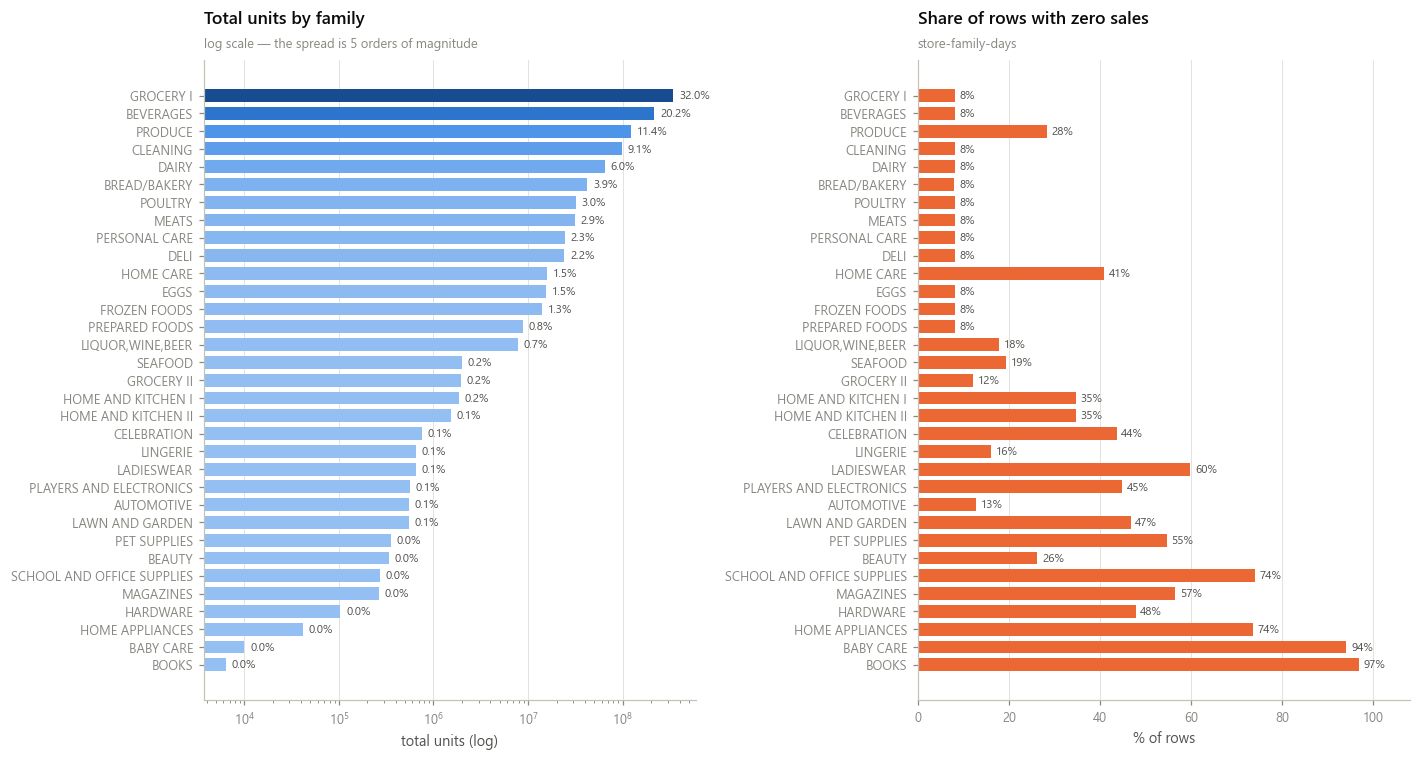

Top 5 families = 79% of all units sold.
Bottom 10 families = 0.23% of all units sold but 30% of the rows to predict.


In [14]:
fam = (train.groupby("family", observed=True)
       .agg(total=("sales", "sum"), mean=("sales", "mean"),
            zero_frac=("sales", lambda x: (x == 0).mean()))
       .sort_values("total", ascending=False))
fam["share"] = fam.total / fam.total.sum()
fam["cum_share"] = fam.share.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

order = fam.index[::-1]
norm = (fam.share[::-1] - fam.share.min()) / (fam.share.max() - fam.share.min())
axes[0].barh(order, fam.total[::-1], color=SEQ(0.2 + 0.65 * norm.values), height=0.72)
axes[0].set_xscale("log")
for y, (t, sh) in enumerate(zip(fam.total[::-1], fam.share[::-1])):
    axes[0].text(t * 1.15, y, f"{sh:.1%}", va="center", fontsize=7.5, color=SECOND)
finish(axes[0], "Total units by family", "log scale — the spread is 5 orders of magnitude",
       xlabel="total units (log)", ygrid=False, xgrid=True)

axes[1].barh(order, fam.zero_frac[::-1] * 100, color=CAT[1], height=0.72)
for y, z in enumerate(fam.zero_frac[::-1]):
    axes[1].text(z * 100 + 1, y, f"{z:.0%}", va="center", fontsize=7.5, color=SECOND)
axes[1].set_xlim(0, 108)
finish(axes[1], "Share of rows with zero sales", "store-family-days", xlabel="% of rows",
       ygrid=False, xgrid=True)
axes[1].tick_params(labelleft=True)

fig.tight_layout(); plt.show()

print(f"Top 5 families = {fam.cum_share.iloc[4]:.0%} of all units sold.")
print(f"Bottom 10 families = {fam.share.tail(10).sum():.2%} of all units sold "
      f"but {10/len(fam):.0%} of the rows to predict.")

store x family combinations           : 1,782
  never sold anything, ever           :    53  (3.0%)
  sold nothing in the last 60 days    :    96  (5.4%)
  -> went dormant during the panel    :    43


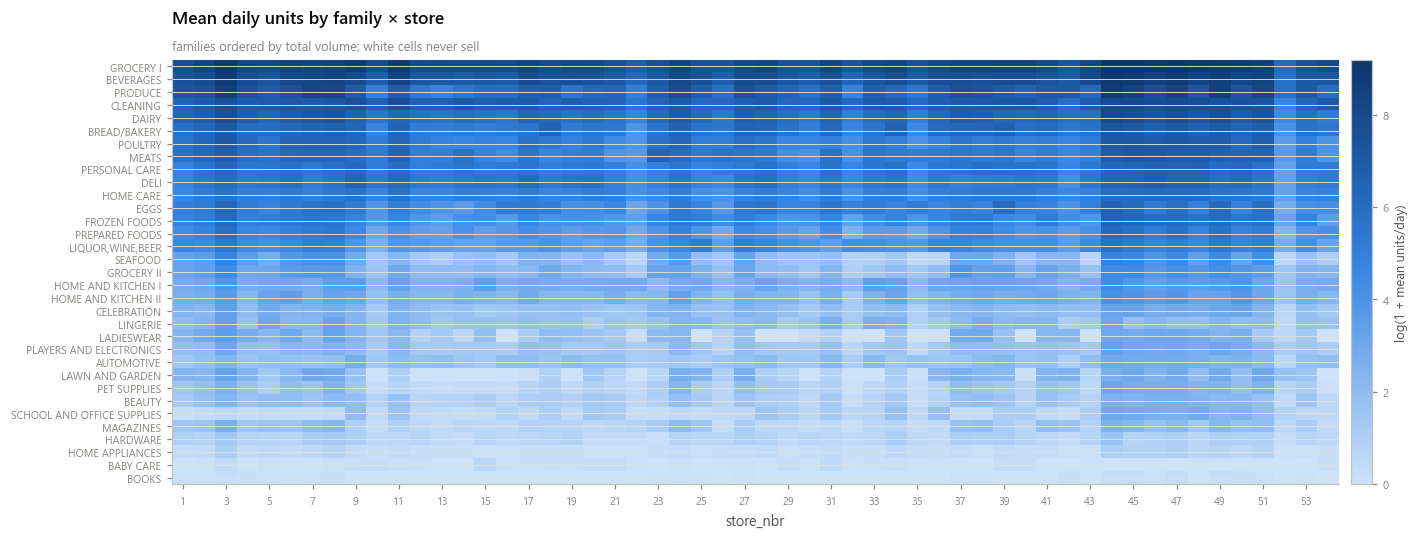

In [15]:
# Separate structural zeros (never stocked) from stock-outs / dormancy.
combo = train.groupby(["store_nbr", "family"], observed=True).sales.sum()
never = combo == 0

recent = train[train.date > train.date.max() - pd.Timedelta(days=60)]
dead_recent = recent.groupby(["store_nbr", "family"], observed=True).sales.sum() == 0

print(f"store x family combinations           : {len(combo):,}")
print(f"  never sold anything, ever           : {never.sum():>5}  ({never.mean():.1%})")
print(f"  sold nothing in the last 60 days    : {dead_recent.sum():>5}  ({dead_recent.mean():.1%})")
print(f"  -> went dormant during the panel    : {(dead_recent & ~never).sum():>5}")

fig, ax = plt.subplots(figsize=(13, 5))
grid = (train.groupby(["family", "store_nbr"], observed=True).sales.mean()
        .unstack("store_nbr"))
grid = grid.loc[fam.index]
im = ax.imshow(np.log1p(grid.values), aspect="auto", cmap=SEQ, interpolation="nearest")
ax.set_yticks(range(len(grid))); ax.set_yticklabels(grid.index, fontsize=7)
ax.set_xticks(range(0, len(grid.columns), 2))
ax.set_xticklabels(grid.columns[::2], fontsize=7)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.02)
cb.set_label("log(1 + mean units/day)", color=SECOND, fontsize=8.5)
cb.ax.tick_params(labelsize=7.5, color=MUTED)
finish(ax, "Mean daily units by family × store",
       "families ordered by total volume; white cells never sell", "store_nbr", "")
fig.tight_layout(); plt.show()

**Read.** Volume is heavily concentrated — the top five families are 79% of all units —
but RMSLE does not care about volume. `BOOKS` is 97% zeros and `BABY CARE` 94%; every one
of their rows carries the same weight as a `GROCERY I` row. The bottom ten families are
0.2% of units sold and 30% of the rows to be predicted.

The heatmap shows the zeros are largely *structural*: the white bands are whole families a
store simply does not carry. 53 combinations never sold a unit in 4.5 years, and 96 sold
nothing in the last 60 days — 43 of which were active earlier and went dormant.

The obvious move is to hard-code 0 for dormant series. §13 tests that rule rather than
assuming it, and the result is a useful surprise — worth reading before building it in.

---
## 6 · `onpromotion`

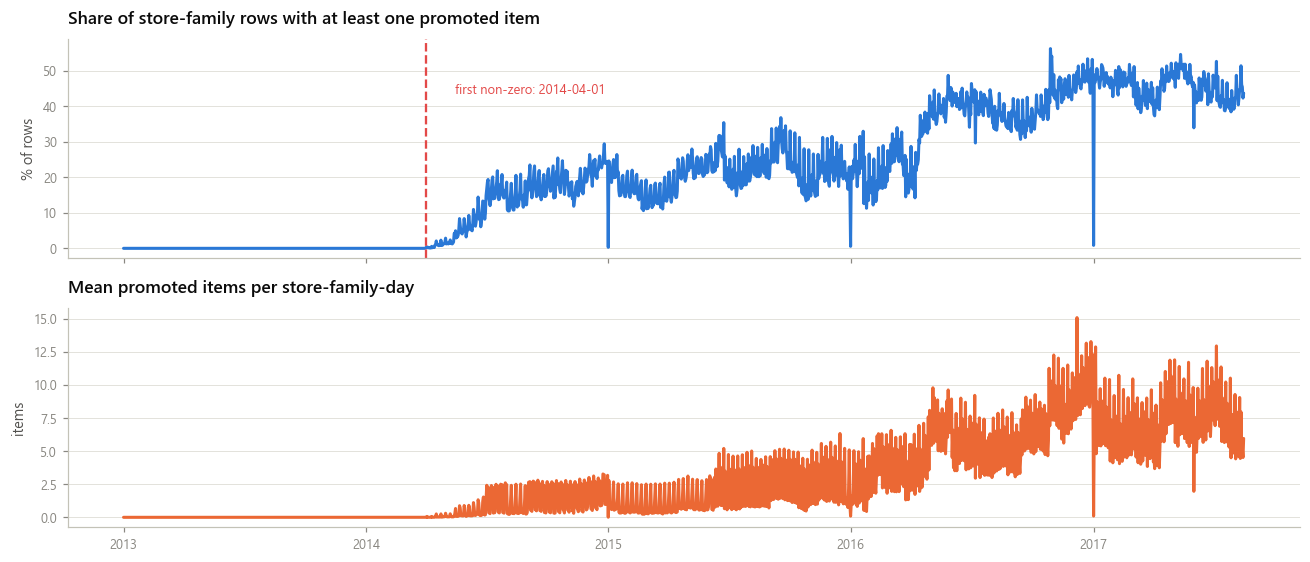

onpromotion is identically zero before 2014-04-01: True
test window mean onpromotion : 6.97
last 16 train days mean      : 5.92


In [16]:
promo_daily = train.groupby("date").onpromotion.agg(["mean", lambda x: (x > 0).mean()])
promo_daily.columns = ["mean_items", "share_rows"]

fig, axes = plt.subplots(2, 1, figsize=(12, 5.2), sharex=True)
axes[0].plot(promo_daily.index, promo_daily.share_rows * 100, color=CAT[0])
axes[0].axvline(pd.Timestamp("2014-04-01"), color=CAT[7], lw=1.5, ls="--")
axes[0].annotate("first non-zero: 2014-04-01",
                 xy=(pd.Timestamp("2014-05-15"), 0.75), xycoords=("data", "axes fraction"),
                 color=CAT[7], fontsize=8.5)
finish(axes[0], "Share of store-family rows with at least one promoted item",
       ylabel="% of rows")

axes[1].plot(promo_daily.index, promo_daily.mean_items, color=CAT[1])
finish(axes[1], "Mean promoted items per store-family-day", ylabel="items")
fig.tight_layout(); plt.show()

print("onpromotion is identically zero before 2014-04-01:",
      bool((train.loc[train.date < "2014-04-01", "onpromotion"] == 0).all()))
print(f"test window mean onpromotion : {test.onpromotion.mean():.2f}")
print(f"last 16 train days mean      : "
      f"{train[train.date > train.date.max()-pd.Timedelta(days=16)].onpromotion.mean():.2f}")

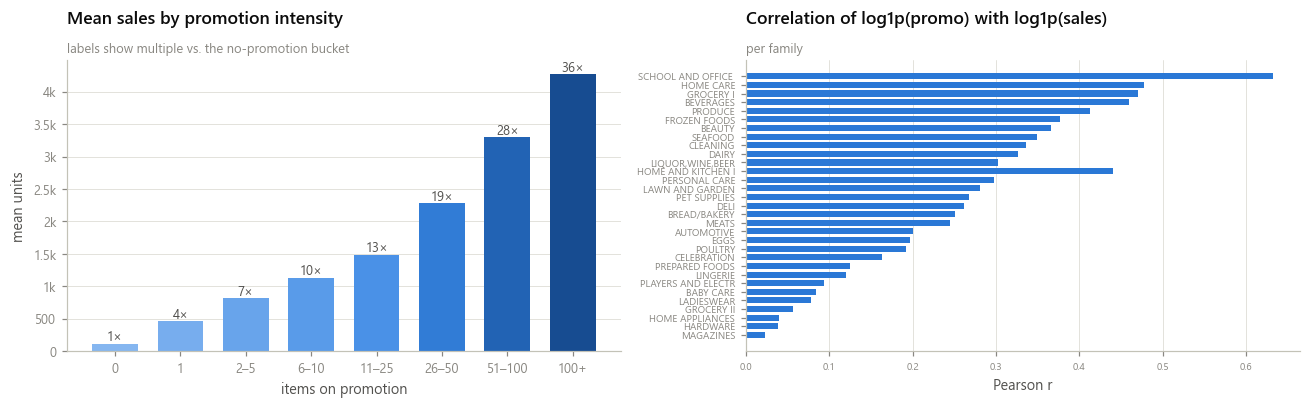

In [17]:
# Lift: compare like with like -- within each family, promo vs no promo, post-2014-04.
post = train[train.date >= "2014-04-01"]
bins = [-1, 0, 1, 5, 10, 25, 50, 100, 10_000]
labels = ["0", "1", "2–5", "6–10", "11–25", "26–50", "51–100", "100+"]
post = post.assign(bucket=pd.cut(post.onpromotion, bins=bins, labels=labels))

g = post.groupby("bucket", observed=True).agg(mean_sales=("sales", "mean"),
                                              rows=("sales", "size"))
base = g.mean_sales.iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
norm = (g.mean_sales - g.mean_sales.min()) / (g.mean_sales.max() - g.mean_sales.min())
b = axes[0].bar(g.index.astype(str), g.mean_sales, color=SEQ(0.25 + 0.6 * norm.values), width=0.7)
for bar, v in zip(b, g.mean_sales):
    axes[0].text(bar.get_x() + bar.get_width()/2, v, f"{v/base:.0f}×", ha="center",
                 va="bottom", fontsize=8.5, color=SECOND)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(axes[0], "Mean sales by promotion intensity",
       "labels show multiple vs. the no-promotion bucket", "items on promotion", "mean units")

corr_fam = (post.groupby("family", observed=True)
            .apply(lambda x: np.corrcoef(np.log1p(x.onpromotion), np.log1p(x.sales))[0, 1])
            .dropna().sort_values())
axes[1].barh([f[:18] for f in corr_fam.index], corr_fam.values, color=CAT[0], height=0.7)
axes[1].tick_params(labelsize=6.5)
finish(axes[1], "Correlation of log1p(promo) with log1p(sales)", "per family",
       xlabel="Pearson r", ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

**Read.** `onpromotion` is **structurally zero before 2014-04-01** — the field was not
recorded, not "no promotions ran". Training a promo coefficient on 2013 data would learn
from a null signal. Either drop pre-April-2014 rows for promo-aware models, or add an
explicit `promo_recorded` indicator.

Where it exists the signal is strong and monotone — the heaviest promotion bucket averages
an order of magnitude more units than the no-promo bucket, and the per-family correlations
are positive for nearly every family. Crucially, **`onpromotion` is given for the test
window**, so it is a true known-future covariate: no forecasting of the feature required.

---
## 7 · Oil price

oil rows given            : 1,218  (business days only)
calendar days spanned     : 1,704
explicit NaNs in file     : 43
NaNs after reindex+interp : 0


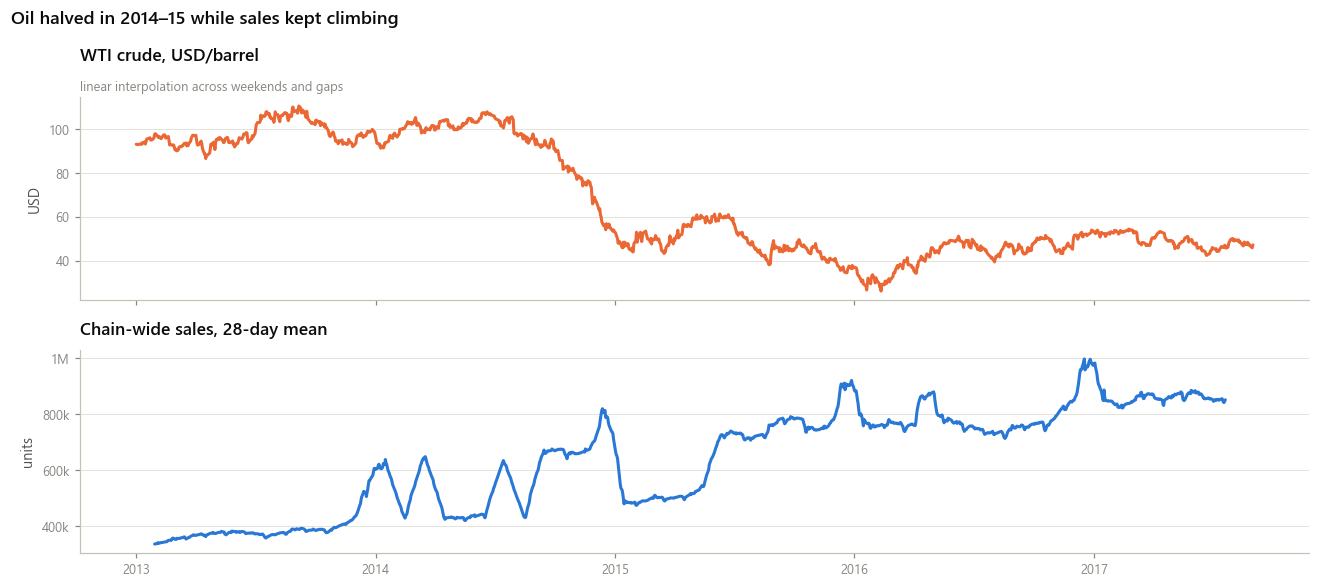


correlation, levels          : -0.624
correlation, daily changes   : -0.001
correlation, 28d-smoothed    : -0.798


In [18]:
oil_full = (oil.set_index("date").reindex(pd.date_range(oil.date.min(), oil.date.max()))
            .rename_axis("date"))
oil_full["filled"] = oil_full.dcoilwtico.interpolate("linear").bfill()

print(f"oil rows given            : {len(oil):,}  (business days only)")
print(f"calendar days spanned     : {len(oil_full):,}")
print(f"explicit NaNs in file     : {oil.dcoilwtico.isna().sum()}")
print(f"NaNs after reindex+interp : {oil_full.filled.isna().sum()}")

joined = daily.set_index("date").join(oil_full["filled"]).dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 5.4), sharex=True)
axes[0].plot(oil_full.index, oil_full.filled, color=CAT[1])
finish(axes[0], "WTI crude, USD/barrel", "linear interpolation across weekends and gaps",
       ylabel="USD")
axes[1].plot(joined.index, joined.sales.rolling(28, center=True).mean(), color=CAT[0])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(axes[1], "Chain-wide sales, 28-day mean", ylabel="units")
fig.suptitle("Oil halved in 2014–15 while sales kept climbing", x=0.005, ha="left",
             fontsize=12, fontweight="semibold", color=INK)
fig.tight_layout(); plt.show()

lv = joined.sales.corr(joined.filled)
df_ = joined.diff().dropna()
print(f"\ncorrelation, levels          : {lv:+.3f}")
print(f"correlation, daily changes   : {df_.sales.corr(df_.filled):+.3f}")
print(f"correlation, 28d-smoothed    : "
      f"{joined.sales.rolling(28).mean().corr(joined.filled.rolling(28).mean()):+.3f}")

**Read.** Oil and sales are negatively correlated in levels (−0.62), and the correlation
strengthens to −0.80 once both are smoothed over 28 days. That looks compelling until you
difference them: at the daily-change level the correlation is **−0.001**. The level
correlation is two coincident trends, not a relationship — oil fell through 2014–15 while
the chain grew. Smoothing does not remove that confound, it amplifies it.

Practical conclusion: oil is a **slow macro covariate, not a daily driver**. Over a 16-day
horizon it is nearly constant, so it can contribute almost nothing to this particular
forecast. §12 pushes this further — detrending and within-year tercile comparison — and the
verdict there is to drop the feature outright.

---
## 8 · Holidays

The raw file cannot be joined as-is. Four rules have to be applied first:

| `type` | Meaning | Handling |
|---|---|---|
| `Holiday` with `transferred=True` | Officially falls here, **but was moved** | Not a holiday — drop |
| `Transfer` | The date it was actually celebrated | **Is** a holiday |
| `Bridge` | Extra day added to extend a break | Is a holiday |
| `Work Day` | Normally-off day worked to repay a `Bridge` | **Not** a holiday — flag separately |
| `Additional` | Day appended to a calendar holiday | Is a holiday |
| `Event` | Non-holiday event (Black Friday, World Cup…) | Keep as its own flag |

`locale` then decides *who* it applies to: `National` (all stores), `Regional` (matched on
`state`), `Local` (matched on `city`).

In [19]:
h = hol.copy()

# 1. A transferred holiday did NOT happen on its listed date.
h = h[~((h.type == "Holiday") & (h.transferred))]
# 2. A Transfer row IS the celebration.
h.loc[h.type == "Transfer", "type"] = "Holiday"
# 3. Work Day is a working day, kept aside as its own signal.
work_days = set(h.loc[h.type == "Work Day", "date"])
h = h[h.type != "Work Day"]
# 4. Events are not holidays.
events = h[h.type == "Event"]
h = h[h.type != "Event"]

print(h.type.value_counts().to_string())
print(f"\nWork Day dates kept aside : {len(work_days)}")
print(f"Event rows kept aside     : {len(events)}")
print(f"Duplicate (date, locale_name) pairs: {h.duplicated(['date','locale_name']).sum()}")

nat = set(h.loc[h.locale == "National", "date"])
reg = set(zip(h.loc[h.locale == "Regional", "date"], h.loc[h.locale == "Regional", "locale_name"]))
loc = set(zip(h.loc[h.locale == "Local", "date"], h.loc[h.locale == "Local", "locale_name"]))
print(f"\nnational holiday dates: {len(nat)} | regional pairs: {len(reg)} | local pairs: {len(loc)}")

type
Holiday       221
Additional     51
Bridge          5

Work Day dates kept aside : 5
Event rows kept aside     : 56
Duplicate (date, locale_name) pairs: 4

national holiday dates: 102 | regional pairs: 24 | local pairs: 147


In [20]:
# Attach store geography, then flag each row at the right granularity.
geo = stores.set_index("store_nbr")[["city", "state"]]
flags = train[["date", "store_nbr", "sales"]].join(geo, on="store_nbr")

flags["nat_hol"] = flags.date.isin(nat)
flags["reg_hol"] = pd.MultiIndex.from_arrays([flags.date, flags.state]).isin(reg)
flags["loc_hol"] = pd.MultiIndex.from_arrays([flags.date, flags.city]).isin(loc)
flags["work_day"] = flags.date.isin(work_days)
flags["any_hol"] = flags[["nat_hol", "reg_hol", "loc_hol"]].any(axis=1)

rows = []
baseline = flags.loc[~flags.any_hol & ~flags.work_day, "sales"].mean()
for label, mask in [("National holiday", flags.nat_hol),
                    ("Regional holiday", flags.reg_hol),
                    ("Local holiday", flags.loc_hol),
                    ("Work Day (payback)", flags.work_day),
                    ("Ordinary day", ~flags.any_hol & ~flags.work_day)]:
    rows.append({"day type": label, "rows": int(mask.sum()),
                 "mean units": flags.loc[mask, "sales"].mean(),
                 "vs ordinary": flags.loc[mask, "sales"].mean() / baseline - 1})
effect = pd.DataFrame(rows)
effect["vs ordinary"] = effect["vs ordinary"].map(lambda v: f"{v:+.1%}")
effect

,day type,rows,mean units,vs ordinary
0,National holiday,138996,424.447,+19.8%
1,Regional holiday,1023,229.725,-35.1%
2,Local holiday,11880,427.115,+20.6%
3,Work Day (payback),8910,372.158,+5.1%
4,Ordinary day,2840310,354.225,+0.0%


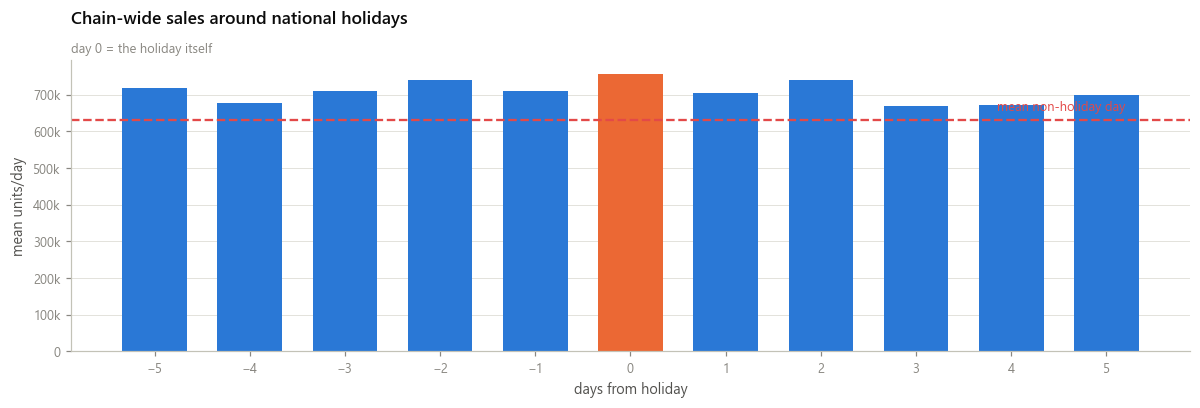

In [21]:
# The proximity effect: sales around national holidays, day by day.
nat_dates = pd.DatetimeIndex(sorted(nat))
daily_idx = daily.set_index("date").sales
offsets = range(-5, 6)
prof = {}
for k in offsets:
    targets = nat_dates + pd.Timedelta(days=k)
    prof[k] = daily_idx.reindex(targets).mean()
prof = pd.Series(prof)
ordinary = daily_idx[~daily_idx.index.isin(nat_dates)].mean()

fig, ax = plt.subplots(figsize=(11, 3.8))
cols = [CAT[1] if k == 0 else CAT[0] for k in prof.index]
ax.bar(prof.index, prof.values, color=cols, width=0.68)
ax.axhline(ordinary, color=CAT[7], lw=1.5, ls="--")
ax.annotate("mean non-holiday day", xy=(5.2, ordinary), color=CAT[7], fontsize=8.5,
            va="center", ha="right", xytext=(0, 8), textcoords="offset points")
ax.set_xticks(list(offsets))
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "Chain-wide sales around national holidays",
       "day 0 = the holiday itself", "days from holiday", "mean units/day")
fig.tight_layout(); plt.show()

**Read — but treat these numbers as provisional.** On a ratio-of-means basis national
holidays run +20% against an ordinary day and local holidays +21% for the affected city.
`Work Day` dates land at +5%, close to ordinary, which confirms that treating them as
working days rather than holidays was the right call.

Two of these figures do not survive proper controls. Holidays are not evenly distributed
across weekdays, and pooling rows across store×family lets the *composition* of the
comparison group shift with the event. **§12 re-estimates all of them at p90 with series
and weekday held fixed** — the national effect splits into a large weekday effect and a
zero weekend effect, and the local effect turns out to be mostly a city-composition
artefact. Read §12 before building any of these into a feature.

**Regional holidays read −35% on only 1,023 rows** across 24 (date, state) pairs — far too
little to trust. §12 confirms no series has more than 5 observations.

Local holidays must be joined on `(date, city)`, never broadcast nationally. Note the file
covers dates *past* the test window (through 2017-12-26), so the calendar is fully
available for the forecast horizon — another known-future covariate.

---
## 9 · The April 2016 earthquake

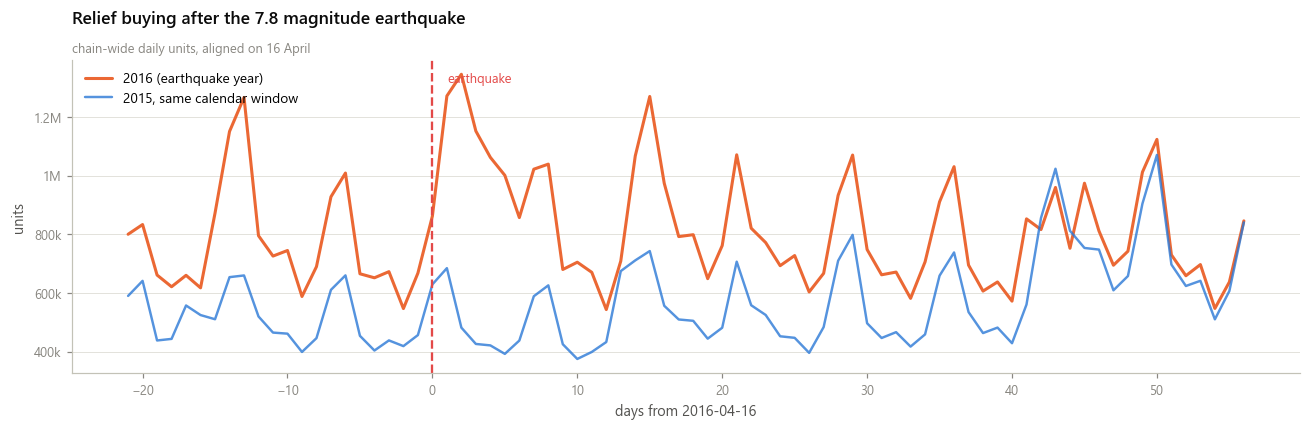

28 days before : 761,229 units/day
15 days after  : 932,568 units/day   (+22.5%)

Largest family-level jumps (mean units after / before):
family
SCHOOL AND OFFICE SUPPLIES   3.181
HOME APPLIANCES              2.576
MAGAZINES                    1.749
PLAYERS AND ELECTRONICS      1.554
PERSONAL CARE                1.481
GROCERY I                    1.450
HOME CARE                    1.360
BEVERAGES                    1.271


In [22]:
quake = pd.Timestamp("2016-04-16")
win = daily.set_index("date").sales.loc[quake - pd.Timedelta(days=21): quake + pd.Timedelta(days=56)]

# Same calendar window one year earlier, as the counterfactual.
quake_ly = quake - pd.Timedelta(days=364)   # 364 keeps the weekday alignment
prior = daily.set_index("date").sales.loc[quake_ly - pd.Timedelta(days=21):
                                          quake_ly + pd.Timedelta(days=56)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(-21, -21 + len(win)), win.values, color=CAT[1], label="2016 (earthquake year)")
ax.plot(range(-21, -21 + len(prior)), prior.values, color=CAT[0], lw=1.6, alpha=0.8,
        label="2015, same calendar window")
ax.axvline(0, color=CAT[7], lw=1.5, ls="--")
ax.annotate("earthquake", xy=(1, 0.93), xycoords=("data", "axes fraction"),
            color=CAT[7], fontsize=8.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(ax, "Relief buying after the 7.8 magnitude earthquake",
       "chain-wide daily units, aligned on 16 April", "days from 2016-04-16", "units")
ax.legend(loc="upper left")
fig.tight_layout(); plt.show()

before = daily.set_index("date").sales.loc[quake - pd.Timedelta(days=28): quake - pd.Timedelta(days=1)].mean()
after = daily.set_index("date").sales.loc[quake: quake + pd.Timedelta(days=14)].mean()
print(f"28 days before : {before:,.0f} units/day")
print(f"15 days after  : {after:,.0f} units/day   ({after/before - 1:+.1%})")

top_shift = (train[train.date.between(quake, quake + pd.Timedelta(days=14))]
             .groupby("family", observed=True).sales.mean() /
             train[train.date.between(quake - pd.Timedelta(days=28), quake - pd.Timedelta(days=1))]
             .groupby("family", observed=True).sales.mean()).sort_values(ascending=False)
print("\nLargest family-level jumps (mean units after / before):")
print(top_shift.head(8).to_string())

**Read.** The earthquake produced a sharp, temporary demand spike concentrated in
first-need goods. It is a genuine one-off: nothing in the test window resembles it.

The +22.5% over 15 days quoted above is again a ratio of means over a window whose weekday
mix differs from the baseline. **§12 re-measures the decay week by week against each day's
own weekday baseline** and finds the shock is far shorter than this chart suggests — which
narrows the dummy considerably.

Either way, treat it as a **contaminated region of the training data**: an explicit dummy,
down-weighting, or exclusion. Doing nothing risks a model learning an April bump that does
not exist in 2017 — though the test window is August, so the risk falls on any
yearly-seasonal component, not on short lags.

---
## 10 · Transactions

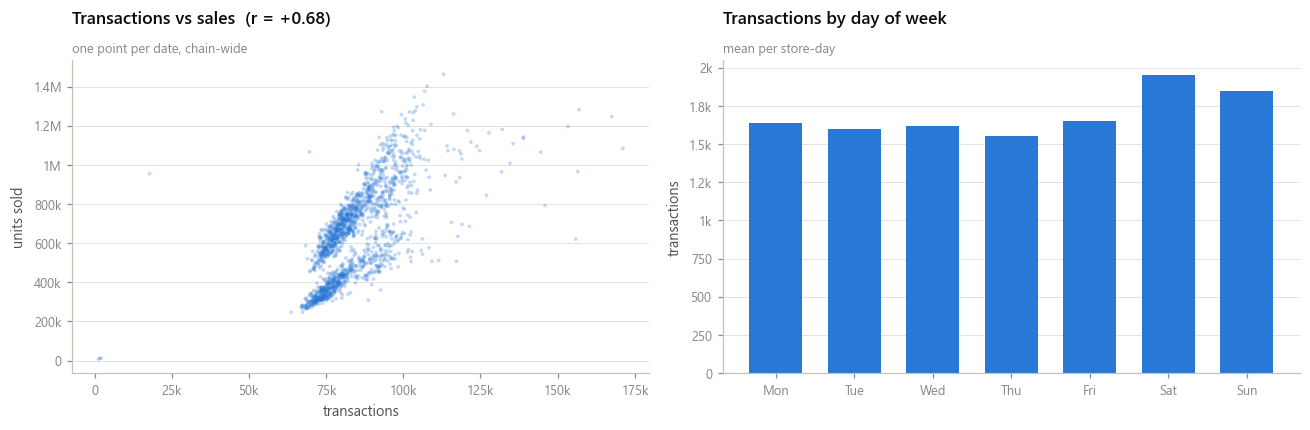

correlation, chain-wide daily : +0.676
correlation, store-day level  : +0.837

transactions.csv covers 2013-01-01 -> 2017-08-15
test window starts       2017-08-16
Transactions are NOT provided for the test window.


In [23]:
tx_daily = txn.groupby("date").transactions.sum()
j = daily.set_index("date").join(tx_daily).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(j.transactions, j.sales, s=6, color=CAT[0], alpha=0.28, edgecolors="none")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(thousands))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(axes[0], f"Transactions vs sales  (r = {j.transactions.corr(j.sales):+.2f})",
       "one point per date, chain-wide", "transactions", "units sold")

tx_dow = txn.groupby(txn.date.dt.dayofweek).transactions.mean()
axes[1].bar(names, tx_dow.values, color=CAT[0], width=0.68)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(thousands))
finish(axes[1], "Transactions by day of week", "mean per store-day", ylabel="transactions")
fig.tight_layout(); plt.show()

store_day = (train.groupby(["date", "store_nbr"], observed=True).sales.sum()
             .rename("sales").reset_index().merge(txn, on=["date", "store_nbr"]))
print(f"correlation, chain-wide daily : {j.transactions.corr(j.sales):+.3f}")
print(f"correlation, store-day level  : {store_day.sales.corr(store_day.transactions):+.3f}")
print()
print(f"transactions.csv covers {txn.date.min():%Y-%m-%d} -> {txn.date.max():%Y-%m-%d}")
print(f"test window starts       {test.date.min():%Y-%m-%d}")
print("Transactions are NOT provided for the test window.")

**Read — leakage warning.** Transactions track sales closely — r = +0.68 chain-wide, and
+0.84 at the store-day level where the comparison is like-for-like. That makes them look
like an excellent feature. They are not directly usable: the file **stops at the last
training date**. Using same-day transactions would build a model that cannot be scored.

Legitimate uses: *lagged* transactions (≥16 days back), or historical per-store
transaction aggregates as a store-profile feature. Anything contemporaneous is off limits.

---
## 11 · Autocorrelation and lag structure

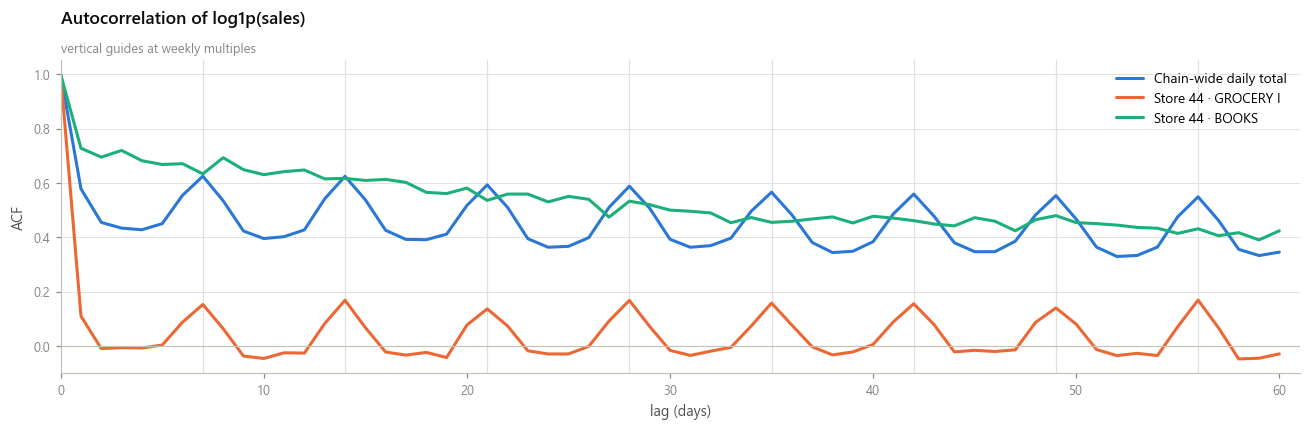

In [24]:
def acf(x, nlags=60):
    """Sample autocorrelation without a statsmodels dependency."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = (x ** 2).sum()
    return np.array([1.0] + [(x[k:] * x[:-k]).sum() / denom for k in range(1, nlags + 1)])

series = {
    "Chain-wide daily total": daily.set_index("date").sales,
    "Store 44 · GROCERY I": train[(train.store_nbr == 44) & (train.family == "GROCERY I")]
                              .set_index("date").sales,
    "Store 44 · BOOKS": train[(train.store_nbr == 44) & (train.family == "BOOKS")]
                          .set_index("date").sales,
}

fig, ax = plt.subplots(figsize=(12, 4))
for i, (label, sr) in enumerate(series.items()):
    a = acf(np.log1p(sr.values), 60)
    ax.plot(range(len(a)), a, color=CAT[i], label=label)
for k in (7, 14, 21, 28, 35, 42, 49, 56):
    ax.axvline(k, color=GRID, lw=0.8, zorder=0)
ax.axhline(0, color=BASELINE, lw=0.8)
ax.set_xlim(0, 61)
finish(ax, "Autocorrelation of log1p(sales)",
       "vertical guides at weekly multiples", "lag (days)", "ACF")
ax.legend(loc="upper right")
fig.tight_layout(); plt.show()

**Read.** Every series shows pronounced spikes at multiples of 7 — the weekly cycle again,
now confirmed in the correlation structure. High-volume series stay strongly autocorrelated
out past 60 days; the sparse `BOOKS` series has almost no usable structure at all.

Because the horizon is 16 days, **only lags ≥ 16 are available for the whole test window**
without recursive forecasting. Lags 16, 21, 28, 35 and rolling means over those windows are
the natural feature set for a direct multi-step model.

---
## 12 · Effect sizing at the 90th percentile

Every effect quoted so far — holidays +20%, the earthquake +22.5% — was a **ratio of
means**. On this data that measure is untrustworthy for three separate reasons:

1. **The zero mass.** 31% of rows are zero. The mean mixes "how much sells" with "does
   anything sell at all", and an event mostly moves the first.
2. **Composition.** Pooling rows across store×family means the comparison group changes
   with the event. Local holidays land disproportionately in big cities, so a "local
   holiday effect" partly measures *which stores were observed*, not what happened to them.
3. **The day-of-week confound.** Holidays are not uniformly spread across weekdays, and
   day-of-week is the strongest cycle in the data.

This section re-estimates the three big effects with **p90** as the headline statistic,
controlling for series and day-of-week. Several of the earlier numbers do not survive.

In [25]:
ev = train[["date", "store_nbr", "family", "sales"]].join(geo, on="store_nbr")
ev["dow"] = ev.date.dt.dayofweek
ev["nat_hol"] = ev.date.isin(nat)
ev["reg_hol"] = pd.MultiIndex.from_arrays([ev.date, ev.state]).isin(reg)
ev["loc_hol"] = pd.MultiIndex.from_arrays([ev.date, ev.city]).isin(loc)
ev["ordinary"] = (~ev.nat_hol & ~ev.reg_hol & ~ev.loc_hol & ~ev.date.isin(work_days))

# Chain-level daily totals, tagged.
cd = ev.groupby("date").agg(total=("sales", "sum")).reset_index()
cd["dow"] = cd.date.dt.dayofweek
cd["nat_hol"] = cd.date.isin(nat)
cd["ordinary"] = ~cd.nat_hol & ~cd.date.isin(work_days)

prof = pd.DataFrame({
    "quantile": ["p50", "p75", "p90", "p95"],
    "national holiday": [cd.loc[cd.nat_hol, "total"].quantile(q) for q in (.5, .75, .9, .95)],
    "ordinary day":     [cd.loc[cd.ordinary, "total"].quantile(q) for q in (.5, .75, .9, .95)],
})
prof["ratio"] = prof["national holiday"] / prof["ordinary day"]
print("Chain-wide daily total — quantile profile (NOT yet day-of-week controlled)\n")
print(prof.to_string(index=False))

Chain-wide daily total — quantile profile (NOT yet day-of-week controlled)

quantile  national holiday  ordinary day  ratio
     p50       746,301.062   628,488.000  1.187
     p75     1,002,235.312   777,620.938  1.289
     p90     1,137,653.125   941,954.062  1.208
     p95     1,250,330.381 1,049,559.125  1.191


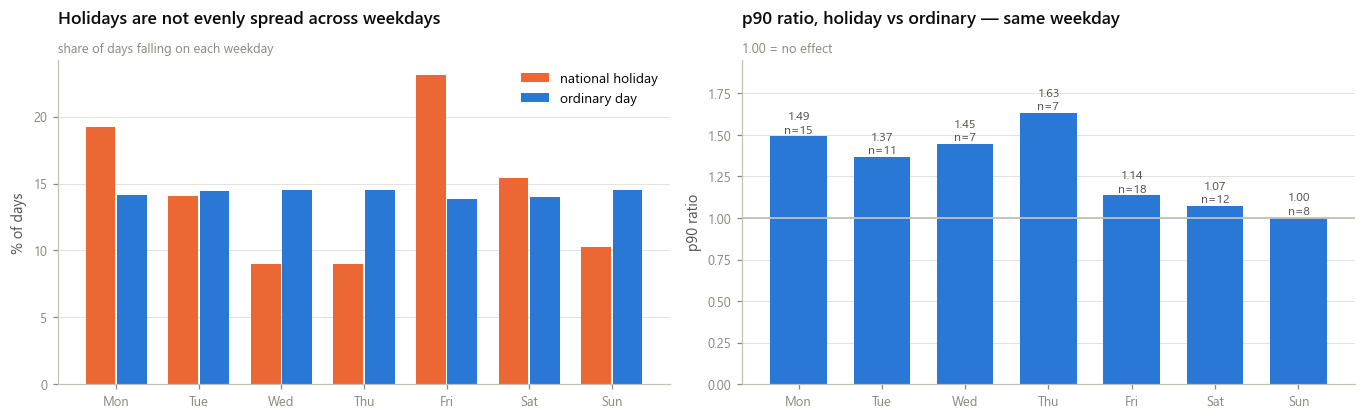

day  n_holidays  p90 ratio
Mon          15      1.492
Tue          11      1.368
Wed           7      1.447
Thu           7      1.632
Fri          18      1.138
Sat          12      1.074
Sun           8      1.002


In [26]:
# The confound: national holidays are not spread evenly across weekdays.
comp = pd.DataFrame({
    "national holiday": cd[cd.nat_hol].dow.value_counts(normalize=True).sort_index(),
    "ordinary day": cd[cd.ordinary].dow.value_counts(normalize=True).sort_index(),
}) * 100
comp.index = names

# Stratified p90 ratio: compare like weekday with like weekday.
strat = []
for d in range(7):
    a = cd[cd.nat_hol & (cd.dow == d)].total
    b = cd[cd.ordinary & (cd.dow == d)].total
    strat.append({"day": names[d], "n_holidays": len(a),
                  "p90 ratio": a.quantile(.9) / b.quantile(.9)})
strat = pd.DataFrame(strat)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))

x = np.arange(7)
axes[0].bar(x - 0.19, comp["national holiday"], width=0.36, color=CAT[1], label="national holiday")
axes[0].bar(x + 0.19, comp["ordinary day"], width=0.36, color=CAT[0], label="ordinary day")
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
finish(axes[0], "Holidays are not evenly spread across weekdays",
       "share of days falling on each weekday", ylabel="% of days")
axes[0].legend(loc="upper right")

cols = [CAT[0] if v >= 1 else CAT[7] for v in strat["p90 ratio"]]
axes[1].bar(strat.day, strat["p90 ratio"], color=cols, width=0.68)
axes[1].axhline(1, color=BASELINE, lw=1.2)
for i, (v, n) in enumerate(zip(strat["p90 ratio"], strat.n_holidays)):
    axes[1].text(i, v, f"{v:.2f}\nn={n}", ha="center", va="bottom", fontsize=8, color=SECOND)
axes[1].set_ylim(0, 1.95)
finish(axes[1], "p90 ratio, holiday vs ordinary — same weekday",
       "1.00 = no effect", ylabel="p90 ratio")

fig.tight_layout(); plt.show()

print(strat.to_string(index=False))

**This is the finding that changes the picture.** A national holiday lifts a *weekday* by
20–63% at p90, and does **nothing at all on a Saturday or Sunday** (1.01 and 0.96).

The mechanism is intuitive once seen: a holiday makes a weekday behave like a weekend.
Weekends are already at peak, so there is no headroom left. The pooled "+20%" from §8 was
averaging a large weekday effect with a zero weekend effect — and the mixture weight was
itself distorted, because 23% of national holidays fall on a Friday against 14% of ordinary
days.

The modelling implication is direct: **`is_holiday` must interact with day-of-week.** A
standalone binary flag will learn the blended average and be wrong in both directions.

national — series compared : 1,607
           median p90 ratio: 1.160   IQR 1.030–1.384
           share above 1.0 : 78.6%


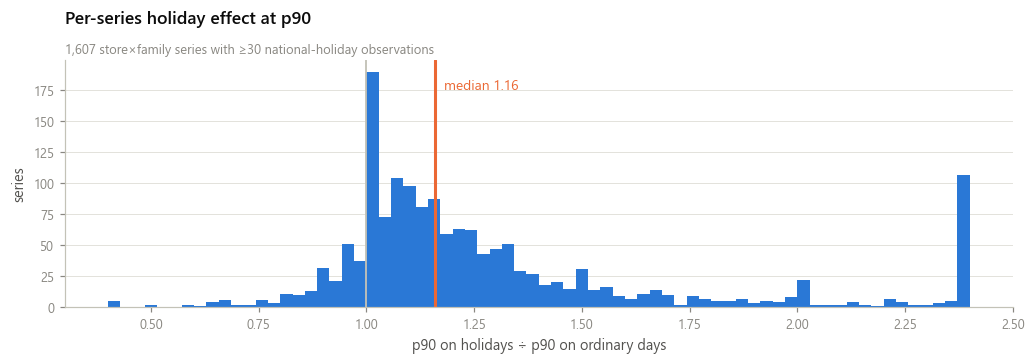

In [27]:
# Series-level view: within each store x family, p90 on holidays vs p90 on ordinary days.
def p90_ratio(mask_col, min_obs=30):
    qh = ev[ev[mask_col]].groupby(["store_nbr", "family"], observed=True).sales.quantile(.9)
    qo = ev[ev.ordinary].groupby(["store_nbr", "family"], observed=True).sales.quantile(.9)
    n = ev[ev[mask_col]].groupby(["store_nbr", "family"], observed=True).sales.size()
    c = pd.DataFrame({"hol": qh, "ord": qo, "n": n}).dropna()
    c = c[(c["ord"] > 0) & (c.n >= min_obs)]
    return (c.hol / c["ord"]).rename("ratio")

r_nat = p90_ratio("nat_hol")
print(f"national — series compared : {len(r_nat):,}")
print(f"           median p90 ratio: {r_nat.median():.3f}"
      f"   IQR {r_nat.quantile(.25):.3f}–{r_nat.quantile(.75):.3f}")
print(f"           share above 1.0 : {(r_nat > 1).mean():.1%}")

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.hist(r_nat.clip(0.4, 2.4), bins=70, color=CAT[0], edgecolor="none")
ax.axvline(1, color=BASELINE, lw=1.2)
ax.axvline(r_nat.median(), color=CAT[1], lw=2)
ax.annotate(f"median {r_nat.median():.2f}", xy=(r_nat.median(), 0.88),
            xycoords=("data", "axes fraction"), xytext=(6, 0), textcoords="offset points",
            color=CAT[1], fontsize=9)
finish(ax, "Per-series holiday effect at p90",
       f"{len(r_nat):,} store×family series with ≥30 national-holiday observations",
       "p90 on holidays ÷ p90 on ordinary days", "series")
fig.tight_layout(); plt.show()

In [28]:
# Metric-aligned effect: mean shift in log1p, controlling for BOTH series and weekday.
ev["lg"] = np.log1p(ev.sales)
ref = (ev[ev.ordinary].groupby(["store_nbr", "family", "dow"], observed=True)
       .lg.mean().rename("ref"))
ev2 = ev.join(ref, on=["store_nbr", "family", "dow"]).dropna(subset=["ref"])

rows = []
for label, mask in [("National holiday", ev2.nat_hol),
                    ("Local holiday", ev2.loc_hol),
                    ("Regional holiday", ev2.reg_hol),
                    ("Ordinary day", ev2.ordinary)]:
    d = ev2.loc[mask, "lg"] - ev2.loc[mask, "ref"]
    rows.append({"day type": label, "rows": int(mask.sum()),
                 "Δ mean log1p": d.mean(), "multiplicative": np.exp(d.mean())})
aligned = pd.DataFrame(rows)
print("Effect in the metric's own units, within (series × weekday):\n")
print(aligned.to_string(index=False))

print("\nRegional holidays — observations per series:")
n_reg = ev[ev.reg_hol].groupby(["store_nbr", "family"], observed=True).sales.size()
print(f"  series touched: {len(n_reg)}   max observations for any series: {n_reg.max()}")

Effect in the metric's own units, within (series × weekday):

        day type    rows  Δ mean log1p  multiplicative
National holiday  138996         0.041           1.041
   Local holiday   11880         0.095           1.100
Regional holiday    1023         0.026           1.026
    Ordinary day 2840310        -0.000           1.000

Regional holidays — observations per series:
  series touched: 231   max observations for any series: 5


**Read — the metric-aligned number is much smaller than any of the headline figures.**

Averaged over every row the way RMSLE actually sees them, and controlling for series *and*
weekday, a national holiday is worth **×1.04** and a local holiday **×1.10**. Compare that
with the §8 ratio-of-means figures of +20% and +21%.

The gap is not a contradiction — the two statistics answer different questions. p90 asks
"what happens at the busy end?" and the answer is a lot, on weekdays. The log-space mean
asks "what happens across all 3 million rows, including the sparse ones?" and the answer is
a little, because most rows barely move. **The second number is the one that bounds how
much a holiday feature can improve RMSLE**, and it says: useful, but not transformative.

**Local holidays were largely a composition artefact.** §8's +21% came from local holidays
landing disproportionately on high-volume city stores. Controlled, the effect is ×1.10 —
real but a third of the headline, and at the store level the median p90 ratio is 0.999.

**Regional holidays are unusable.** No series has more than 5 observations. §8's −35% was
noise, and it should not appear as a feature on its own.

> ⚠️ **These two multipliers are still wrong, and §13 fixes them.** The reference above is
> each series' all-time mean for that weekday — which controls for series and weekday but
> **not for season**. Holidays are not spread evenly through the year (28 of the national
> ones fall in December), and December is the annual peak. So part of what looks like a
> holiday effect here is simply *December*. §13 redoes this against a local baseline and
> both numbers move to ≈ 1.00.

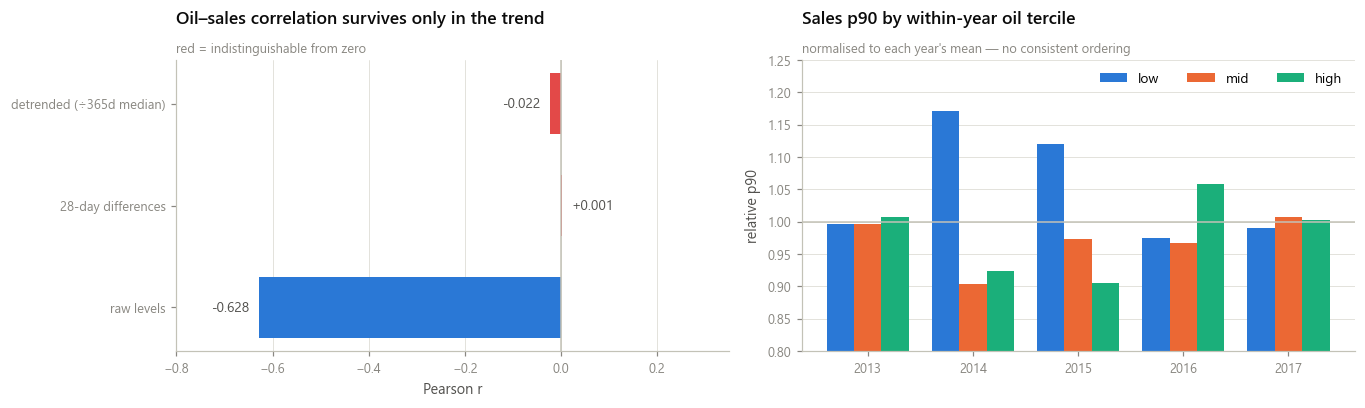

bucket   low   mid  high
2013   0.997 0.996 1.007
2014   1.171 0.904 0.924
2015   1.121 0.974 0.905
2016   0.976 0.967 1.058
2017   0.990 1.008 1.002


In [29]:
# --- OIL: does anything survive detrending? ---------------------------------------
oj = cd.set_index("date")[["total"]].join(oil_full["filled"].rename("oil")).dropna()
oj["s_dt"] = oj.total / oj.total.rolling(365, center=True, min_periods=120).median()
oj["o_dt"] = oj.oil / oj.oil.rolling(365, center=True, min_periods=120).median()
ojd = oj.dropna()

corrs = pd.Series({
    "raw levels": oj.total.corr(oj.oil),
    "28-day differences": oj.total.diff(28).corr(oj.oil.diff(28)),
    "detrended (÷365d median)": ojd.s_dt.corr(ojd.o_dt),
})

# Within-year: split each year into oil terciles, compare sales p90.
oj["year"] = oj.index.year
terc = []
for y, g in oj.groupby("year"):
    if len(g) < 200:
        continue
    g = g.assign(bucket=pd.qcut(g.oil, 3, labels=["low", "mid", "high"], duplicates="drop"))
    q = g.groupby("bucket", observed=True).total.quantile(.9)
    terc.append((q / q.mean()).rename(y))
terc = pd.concat(terc, axis=1).T

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))

cols = [CAT[0] if abs(v) > 0.1 else CAT[7] for v in corrs.values]
axes[0].barh(corrs.index, corrs.values, color=cols, height=0.6)
axes[0].axvline(0, color=BASELINE, lw=1)
for i, v in enumerate(corrs.values):
    axes[0].text(v + (0.02 if v >= 0 else -0.02), i, f"{v:+.3f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=9, color=SECOND)
axes[0].set_xlim(-0.8, 0.35)
finish(axes[0], "Oil–sales correlation survives only in the trend",
       "red = indistinguishable from zero", xlabel="Pearson r", ygrid=False, xgrid=True)

w = 0.26
for i, b in enumerate(["low", "mid", "high"]):
    axes[1].bar(np.arange(len(terc)) + (i - 1) * w, terc[b], width=w, color=CAT[i], label=b)
axes[1].axhline(1, color=BASELINE, lw=1)
axes[1].set_xticks(range(len(terc))); axes[1].set_xticklabels(terc.index)
axes[1].set_ylim(0.8, 1.25)
finish(axes[1], "Sales p90 by within-year oil tercile",
       "normalised to each year's mean — no consistent ordering", ylabel="relative p90")
axes[1].legend(loc="upper right", ncol=3, title=None)

fig.tight_layout(); plt.show()
print(terc.round(3).to_string())

**Read — oil is dead, and this settles it.** The −0.63 level correlation collapses to
**−0.02 after detrending** and **+0.00 on 28-day differences**. The within-year terciles
have no consistent ordering: 2014 and 2015 show higher sales when oil is low, 2016 shows the
opposite, 2013 and 2017 show nothing.

The whole apparent relationship was one slow trend crossing another. **Drop oil.** Carrying
it into a gradient-boosted model invites the tree to split on a trend proxy and overfit the
2014–15 regime.

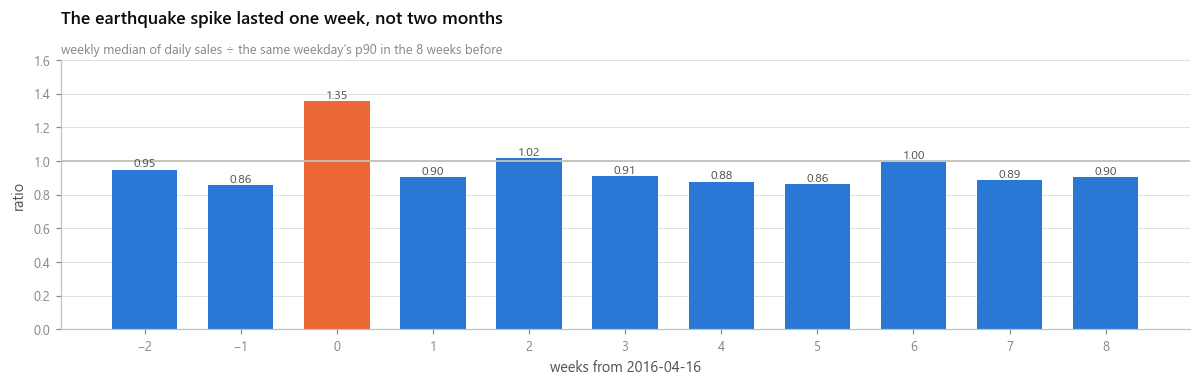

 week   starting  ratio
   -2 2016-04-02  0.949
   -1 2016-04-09  0.857
    0 2016-04-16  1.354
    1 2016-04-23  0.903
    2 2016-04-30  1.018
    3 2016-05-07  0.909
    4 2016-05-14  0.876
    5 2016-05-21  0.862
    6 2016-05-28  0.996
    7 2016-06-04  0.888
    8 2016-06-11  0.902


In [30]:
# --- EARTHQUAKE: how long did it actually last? ------------------------------------
dt_total = cd.set_index("date").total
base_win = dt_total.loc[quake - pd.Timedelta(days=56): quake - pd.Timedelta(days=1)]
dow_base = base_win.groupby(base_win.index.dayofweek).quantile(.9)   # weekday-specific base

weeks = []
for wk in range(-2, 9):
    w = dt_total.loc[quake + pd.Timedelta(days=7*wk): quake + pd.Timedelta(days=7*wk + 6)]
    weeks.append({"week": wk, "starting": w.index.min().date(),
                  "ratio": (w / w.index.dayofweek.map(dow_base)).median()})
weeks = pd.DataFrame(weeks)

fig, ax = plt.subplots(figsize=(11, 3.6))
cols = [CAT[1] if r >= 1.15 else CAT[0] for r in weeks.ratio]
ax.bar(weeks.week, weeks.ratio, color=cols, width=0.68)
ax.axhline(1, color=BASELINE, lw=1.2)
for wk, r in zip(weeks.week, weeks.ratio):
    ax.text(wk, r, f"{r:.2f}", ha="center", va="bottom", fontsize=8, color=SECOND)
ax.set_xticks(weeks.week)
ax.set_ylim(0, 1.6)
finish(ax, "The earthquake spike lasted one week, not two months",
       "weekly median of daily sales ÷ the same weekday's p90 in the 8 weeks before",
       "weeks from 2016-04-16", "ratio")
fig.tight_layout(); plt.show()

print(weeks.to_string(index=False))

**Read.** Once each day is compared with its *own weekday's* pre-quake p90, the shock is
**+35% in week 0 and gone by week 1** (0.90). Weeks 2–8 sit between 0.86 and 1.02 with no
trend — noise around the baseline, not a sustained relief-buying period.

§9's "+22.5% over 15 days" overstated the duration because it compared raw means across a
window whose weekday composition differed from the baseline. The corrected dummy is narrow:
**2016-04-16 to 2016-04-22**, one week, not the April–May block suggested earlier.

That also lowers the stakes. A single contaminated week out of 240 is a rounding error for
a model trained on 4.5 years — worth a dummy, not worth dropping data over.

### Corrected effect sizes

| Effect | §8–§9 headline (ratio of means) | Corrected | What changed |
|---|---|---|---|
| National holiday, weekday | +20% (pooled) | **+20% to +63% at p90** | Weekend dilution removed |
| National holiday, weekend | +20% (pooled) | **≈ 0%** | No headroom at the weekly peak |
| National holiday, all rows | +20% | **×1.04 in log space** | Metric-aligned; bounds the RMSLE gain |
| Local holiday | +21% | **×1.10** | §8 figure was a city-composition artefact |
| Regional holiday | −35% | **unusable** | ≤ 5 observations per series |
| Oil | r = −0.63 | **r = −0.02 detrended** | Trend confounding; drop the feature |
| Earthquake | +22.5% over 15 days | **+35% for 7 days** | Weekday composition inflated the window |

---
## 13 · Holidays are not one thing

§12 controlled for series composition and weekday. It did **not** control for season, and
that omission matters more than the ones it fixed: 28 of the 82 national holiday
occurrences fall in December, the annual peak. Measuring a December holiday against a
series' all-time average partly measures December.

This section uses a **local baseline**: for each holiday occurrence, compare it with the
*same weekday within ±28 days*, excluding other holidays. That neutralises trend, season,
and weekday simultaneously. It also asks the question §8–§12 never did — not "what does a
holiday do?" but **"what does *this* holiday do?"**

Finally it audits the actual forecast window, because a national average is no use if the
16 days being predicted contain one specific municipal holiday.

In [31]:
# Wide log1p panel: dates x series. Christmas rows stay NaN and drop out of the means.
L_panel = (train.assign(family=train.family.astype(str))
           .pivot(index="date", columns=["store_nbr", "family"], values="sales"))
L_panel = np.log1p(L_panel.reindex(calendar))

all_special = set(h.date) | work_days | set(events.date)
col_city = np.array([stores.set_index("store_nbr").city[s]
                     for s in L_panel.columns.get_level_values(0)])

def local_effect(d, cols=None, halo=28):
    """log1p(sales) on date d minus the same weekday within +/-halo days, holidays excluded."""
    win = calendar[(abs((calendar - d).days) <= halo) & (calendar.dayofweek == d.dayofweek)]
    win = win[~win.isin(list(all_special))]
    if len(win) < 3:
        return None
    sub = L_panel if cols is None else L_panel.iloc[:, cols]
    return (sub.loc[d] - sub.loc[win].mean()).dropna()

occ = []
for _, r in h[h.locale == "National"].drop_duplicates(["date", "description"]).iterrows():
    if r.date not in calendar:
        continue
    dl = local_effect(r.date)
    if dl is not None and len(dl):
        occ.append({"scope": "National", "desc": r.description, "date": r.date,
                    "rows": len(dl), "delta": dl.mean()})
for _, r in h[h.locale == "Local"].drop_duplicates(["date", "description"]).iterrows():
    if r.date not in calendar:
        continue
    cols = np.where(col_city == r.locale_name)[0]
    if not len(cols):
        continue
    dl = local_effect(r.date, cols)
    if dl is not None and len(dl):
        occ.append({"scope": "Local", "desc": r.description, "date": r.date,
                    "rows": len(dl), "delta": dl.mean()})

occ = pd.DataFrame(occ)
occ["mult"] = np.exp(occ.delta)

def summarise(scope):
    return (occ[occ.scope == scope].groupby("desc")
            .agg(n=("delta", "size"), rows=("rows", "sum"),
                 delta=("delta", "mean"), sd=("delta", "std"))
            .assign(mult=lambda x: np.exp(x.delta))
            .sort_values("mult"))

nat_eff, loc_eff = summarise("National"), summarise("Local")

for label, tab, s12 in [("National", nat_eff, 1.041), ("Local", loc_eff, 1.100)]:
    sub = occ[occ.scope == label]
    pooled = np.exp(np.average(sub.delta, weights=sub.rows))
    print(f"{label:<9} pooled x{pooled:.3f}   (§12 with the all-time baseline said x{s12:.3f})")
    print(f"{'':<9} spread x{tab.mult.min():.3f} ({tab.mult.idxmin()})"
          f"  ..  x{tab.mult.max():.3f} ({tab.mult.idxmax()})")

National  pooled x1.012   (§12 with the all-time baseline said x1.041)
          spread x0.074 (Primer dia del ano)  ..  x1.858 (Puente Navidad)
Local     pooled x1.018   (§12 with the all-time baseline said x1.100)
          spread x0.769 (Fundacion de Riobamba)  ..  x1.194 (Cantonizacion de Salinas)


**Both pooled numbers collapse to ≈ 1.00 once season is controlled.** The holiday "effect"
§8 measured at +20% and §12 refined to ×1.04 is, correctly measured, **nothing at all on
average**.

But an average is the wrong summary here, as the spread shows.

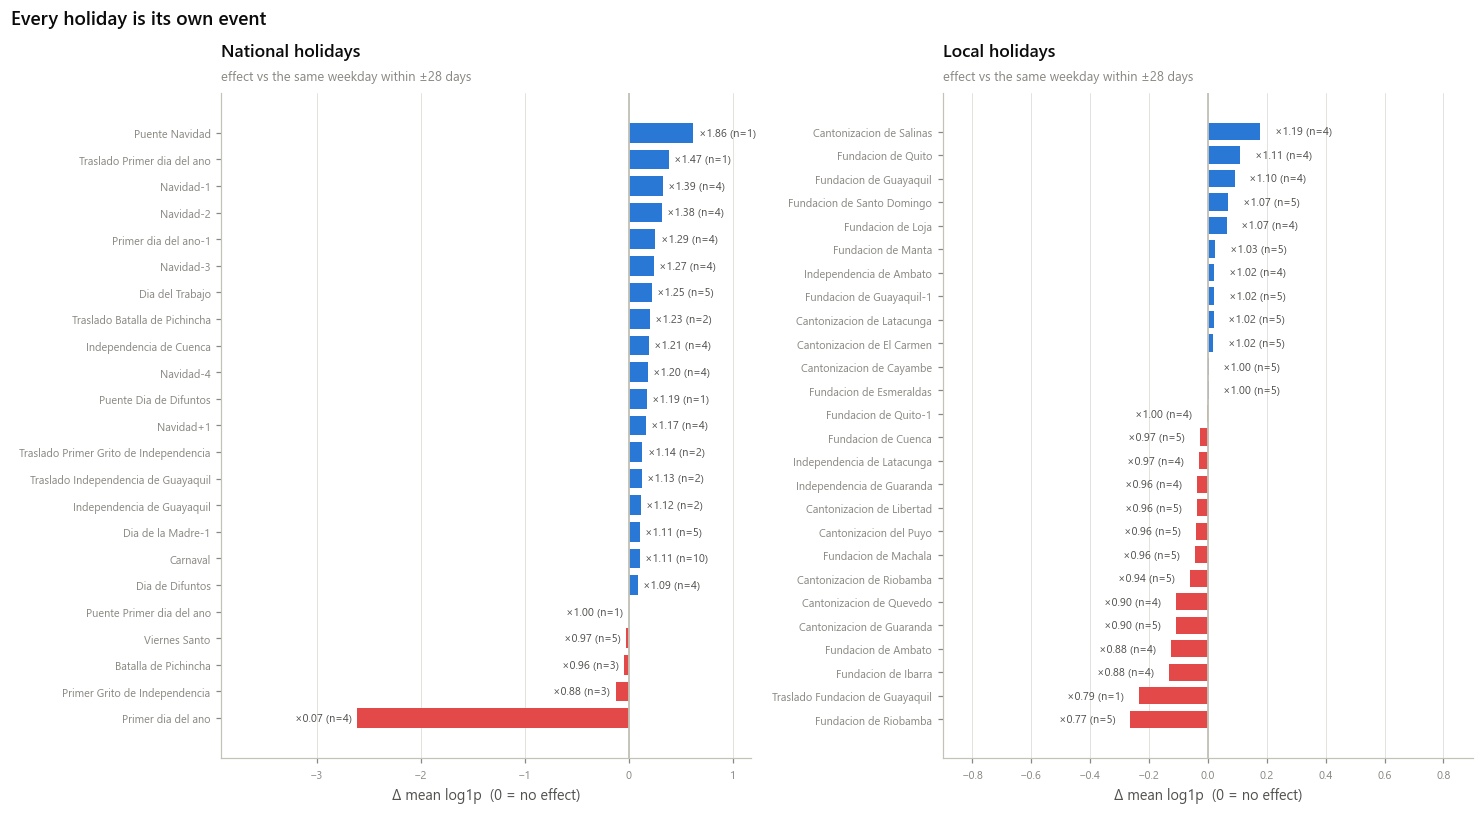

National: 2 names depress sales >5%, 18 lift >5%, 3 are flat
Local   : 14 of 26 depress sales


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 7.5))

for ax, tab, title in [(axes[0], nat_eff, "National holidays"),
                       (axes[1], loc_eff, "Local holidays")]:
    cols = [CAT[0] if v >= 0 else CAT[7] for v in tab.delta]
    ax.barh(tab.index, tab.delta, color=cols, height=0.74)
    ax.axvline(0, color=BASELINE, lw=1.2)
    for y, (dv, mv, nn) in enumerate(zip(tab.delta, tab.mult, tab.n)):
        ax.text(dv + (0.05 if dv >= 0 else -0.05), y, f"×{mv:.2f} (n={nn})",
                va="center", ha="left" if dv >= 0 else "right", fontsize=7.2, color=SECOND)
    ax.set_xlim(min(tab.delta.min() * 1.5, -0.9), max(tab.delta.max() * 1.9, 0.9))
    ax.tick_params(labelsize=7.2)
    finish(ax, title, "effect vs the same weekday within ±28 days",
           xlabel="Δ mean log1p  (0 = no effect)", ygrid=False, xgrid=True)

fig.suptitle("Every holiday is its own event", x=0.005, ha="left", fontsize=12.5,
             fontweight="semibold", color=INK)
fig.tight_layout(); plt.show()

print(f"National: {(nat_eff.mult < 0.95).sum()} names depress sales >5%, "
      f"{(nat_eff.mult > 1.05).sum()} lift >5%, "
      f"{((nat_eff.mult >= .95) & (nat_eff.mult <= 1.05)).sum()} are flat")
print(f"Local   : {(loc_eff.mult < 1).sum()} of {len(loc_eff)} depress sales")

In [33]:
# The extreme case, invisible inside any pooled average.
d_tot = train.groupby("date").sales.sum()
print("New Year's Day — the largest single calendar effect in the dataset\n")
for y in range(2013, 2018):
    j = pd.Timestamp(f"{y}-01-01")
    if j in d_tot.index:
        nxt = d_tot.loc[j + pd.Timedelta(days=3): j + pd.Timedelta(days=9)].mean()
        print(f"  {j:%Y-%m-%d} ({j:%a})   sales {d_tot.loc[j]:>9,.0f}"
              f"   following week {nxt:>10,.0f}   ratio {d_tot.loc[j]/nxt:.4f}")
print(f"\n'Primer dia del ano' multiplier: ×{nat_eff.loc['Primer dia del ano','mult']:.3f}")
print(f"'Puente Navidad'    multiplier: ×{nat_eff.loc['Puente Navidad','mult']:.3f}")
print("\nA binary is_national_holiday flag averages these two together.")

New Year's Day — the largest single calendar effect in the dataset

  2013-01-01 (Tue)   sales     2,512   following week    366,784   ratio 0.0068
  2014-01-01 (Wed)   sales     8,602   following week    675,368   ratio 0.0127
  2015-01-01 (Thu)   sales    12,774   following week    528,437   ratio 0.0242
  2016-01-01 (Fri)   sales    16,433   following week    866,283   ratio 0.0190
  2017-01-01 (Sun)   sales    12,083   following week    920,004   ratio 0.0131

'Primer dia del ano' multiplier: ×0.074
'Puente Navidad'    multiplier: ×1.858

A binary is_national_holiday flag averages these two together.


**This is why the binary flag is worthless.** `is_national_holiday` is asked to represent
both **New Year's Day at ×0.07** — every store shut, chain sales at 0.7–2.4% of normal —
and **Puente Navidad at ×1.86**. Their row-weighted average is ×1.01, which is precisely
the "no effect" §13 opened with.

The signal was never in the flag. It is in the **holiday's identity**, and that is what the
feature has to encode.

Note also `Navidad-4` through `Navidad-1` climbing 1.20 → 1.39: the Christmas run-up is a
real, orderly ramp that a single Christmas flag would flatten entirely.

### Auditing the actual forecast window

A national average is no help if the 16 days being predicted contain one specific municipal
holiday. Two things must be verified: **which holidays fall in the test window**, and
whether the join that assigns them to stores actually connects.

In [34]:
T0, T1 = test.date.min(), test.date.max()

print(f"TEST WINDOW {T0:%Y-%m-%d} .. {T1:%Y-%m-%d}\n")
in_win = hol[(hol.date >= T0) & (hol.date <= T1)]
print("Raw holiday rows inside it:")
print(in_win.to_string(index=False) if len(in_win) else "  none")

# --- join integrity: silent mismatches here would disable the feature entirely ----
cities, states = set(stores.city), set(stores.state)
loc_names = set(hol.loc[hol.locale == "Local", "locale_name"])
reg_names = set(hol.loc[hol.locale == "Regional", "locale_name"])
print(f"\nJoin integrity")
print(f"  Local locale_name -> stores.city    : {len(loc_names & cities)}/{len(loc_names)} matched"
      f"   unmatched: {sorted(loc_names - cities) or 'none'}")
print(f"  Regional locale_name -> stores.state: {len(reg_names & states)}/{len(reg_names)} matched"
      f"   unmatched: {sorted(reg_names - states) or 'none'}")
print(f"  cities that never get a local holiday: {sorted(cities - loc_names)}")

te_geo = test.join(geo, on="store_nbr")
te_flags = {
    "national": te_geo.date.isin(nat).sum(),
    "regional": pd.MultiIndex.from_arrays([te_geo.date, te_geo.state]).isin(reg).sum(),
    "local":    pd.MultiIndex.from_arrays([te_geo.date, te_geo.city]).isin(loc).sum(),
    "work day": te_geo.date.isin(work_days).sum(),
    "event":    te_geo.date.isin(set(events.date)).sum(),
}
print("\nTest rows carrying each flag:")
for k, v in te_flags.items():
    print(f"  {k:<10} {v:>6,}  ({v/len(test):.2%} of the test set)")

hit = te_geo[pd.MultiIndex.from_arrays([te_geo.date, te_geo.city]).isin(loc)]
if len(hit):
    print("\nAffected stores:")
    print(hit.groupby(["date", "city"], observed=True)
          .agg(stores=("store_nbr", lambda s: sorted(set(s))), rows=("id", "size")).to_string())

TEST WINDOW 2017-08-16 .. 2017-08-31

Raw holiday rows inside it:
      date    type locale locale_name         description  transferred
2017-08-24 Holiday  Local      Ambato Fundacion de Ambato        False

Join integrity
  Local locale_name -> stores.city    : 19/19 matched   unmatched: none
  Regional locale_name -> stores.state: 4/4 matched   unmatched: none
  cities that never get a local holiday: ['Babahoyo', 'Daule', 'Playas']

Test rows carrying each flag:
  national        0  (0.00% of the test set)
  regional        0  (0.00% of the test set)
  local          66  (0.23% of the test set)
  work day        0  (0.00% of the test set)
  event           0  (0.00% of the test set)

Affected stores:
                     stores  rows
date       city                  
2017-08-24 Ambato  [23, 50]    66


Fundacion de Ambato — every occurrence in the training data

      date  rows  delta  mult
2013-08-24    66  0.007 1.007
2014-08-24    66 -0.624 0.536
2015-08-24    66  0.079 1.082
2016-08-24    66  0.034 1.035

mean Δlog1p -0.1259  ->  ×0.882
sd 0.3334 across n=4 occurrences   standard error 0.1667
95% CI on the multiplier: ×0.636 .. ×1.222

contains 1.00 (no effect)? YES


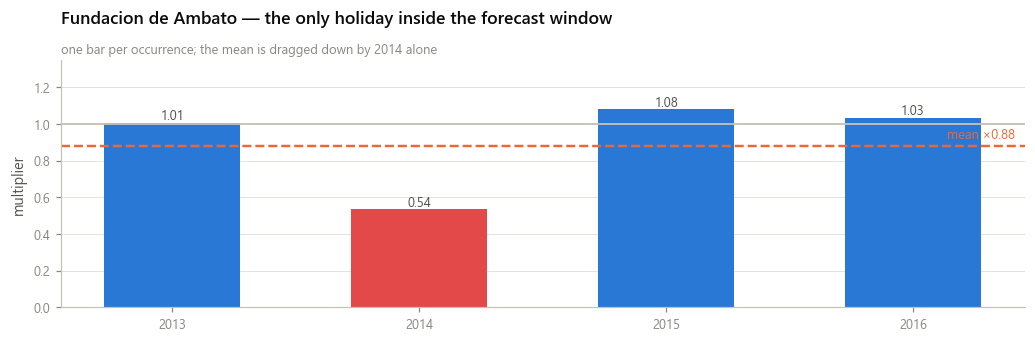

In [35]:
# What does that specific holiday do? And can we even tell?
amb = occ[occ.desc == "Fundacion de Ambato"].sort_values("date")
print("Fundacion de Ambato — every occurrence in the training data\n")
print(amb[["date", "rows", "delta", "mult"]].round(4).to_string(index=False))

m, s, n = amb.delta.mean(), amb.delta.std(), len(amb)
se = s / np.sqrt(n)
lo_ci, hi_ci = m - 1.96 * se, m + 1.96 * se
print(f"\nmean Δlog1p {m:+.4f}  ->  ×{np.exp(m):.3f}")
print(f"sd {s:.4f} across n={n} occurrences   standard error {se:.4f}")
print(f"95% CI on the multiplier: ×{np.exp(lo_ci):.3f} .. ×{np.exp(hi_ci):.3f}")
print(f"\ncontains 1.00 (no effect)? {'YES' if lo_ci < 0 < hi_ci else 'no'}")

fig, ax = plt.subplots(figsize=(9.5, 3.2))
cols = [CAT[0] if v >= 1 else CAT[7] for v in amb.mult]
ax.bar([f"{d:%Y}" for d in amb.date], amb.mult, color=cols, width=0.55)
ax.axhline(1, color=BASELINE, lw=1.2)
ax.axhline(np.exp(m), color=CAT[1], lw=1.6, ls="--")
ax.annotate(f"mean ×{np.exp(m):.2f}", xy=(0.99, np.exp(m)), xycoords=("axes fraction", "data"),
            xytext=(0, 5), textcoords="offset points", color=CAT[1], fontsize=8.5, ha="right")
for i, v in enumerate(amb.mult):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8.5, color=SECOND)
ax.set_ylim(0, 1.35)
finish(ax, "Fundacion de Ambato — the only holiday inside the forecast window",
       "one bar per occurrence; the mean is dragged down by 2014 alone", ylabel="multiplier")
fig.tight_layout(); plt.show()

### The audit's answer

**Exactly one holiday falls in the forecast window:** `Fundacion de Ambato`, 2017-08-24,
**Local**, city Ambato. It touches stores 23 and 50 — **66 of 28,512 test rows, 0.23%**.
No national, regional, work-day or event flag is active anywhere in the window.

**The join is sound.** All 19 local `locale_name` values match a city in `stores.csv` and
all 4 regional values match a state, so nothing is being silently dropped. Three cities
(Babahoyo, Daule, Playas) simply never have a local holiday.

**But the effect is not reliably estimable.** Four occurrences, three of them ≈ 1.0, one
(2014) at 0.54, giving a mean of ×0.88 with a 95% CI of roughly **×0.63 to ×1.24**. That
interval comfortably contains 1.00. The honest statement is *we do not know what this
holiday does*, and any model that claims to is fitting one anomalous Sunday in 2014.

The correct response is not to hard-code ×0.88. It is to hand the model the **holiday's
identity** and let regularisation decide how much to trust four observations — while
knowing that for these 66 rows the honest prior is "close to an ordinary Thursday".

### What this means for the feature set

| | Wrong | Right |
|---|---|---|
| National | `is_national_holiday` ∈ {0,1} | the holiday's **name** as a category |
| Local | `is_local_holiday` ∈ {0,1} | the holiday's **name**, joined on `(date, city)` |
| Regional | any feature at all | drop — ≤ 5 observations per series |
| Christmas | one flag | `Navidad-4 … Navidad+1` are distinct, ordered levels |

---
## 14 · Validation design and naive baselines

The test set is the 16 days immediately after the training data. A validation split must
mirror that exactly — a random split would leak future information through neighbouring
days and produce a wildly optimistic score.

In [36]:
H = test.date.nunique()
valid_start = train.date.max() - pd.Timedelta(days=H - 1)
tr = train[train.date < valid_start]
va = train[train.date >= valid_start]

print(f"horizon          : {H} days")
print(f"fit    : {tr.date.min():%Y-%m-%d} -> {tr.date.max():%Y-%m-%d}  ({len(tr):,} rows)")
print(f"holdout: {va.date.min():%Y-%m-%d} -> {va.date.max():%Y-%m-%d}  ({len(va):,} rows)")
print(f"test   : {test.date.min():%Y-%m-%d} -> {test.date.max():%Y-%m-%d}  ({len(test):,} rows)")

def rmsle(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(np.asarray(y_true, float))) ** 2)))

horizon          : 16 days
fit    : 2013-01-01 -> 2017-07-30  (2,972,376 rows)
holdout: 2017-07-31 -> 2017-08-15  (28,512 rows)
test   : 2017-08-16 -> 2017-08-31  (28,512 rows)


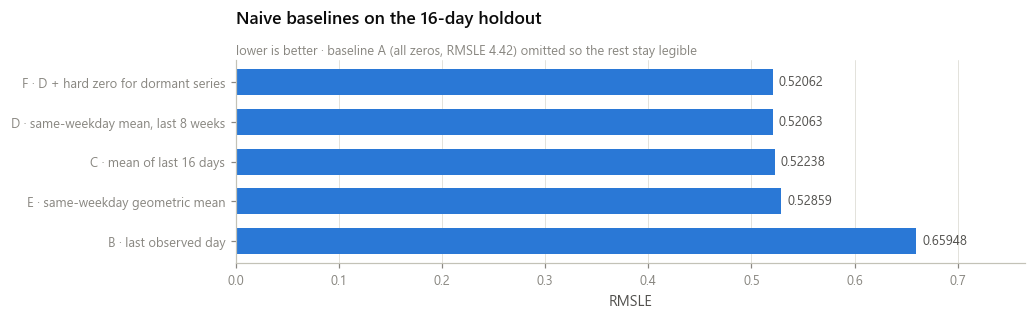

,baseline,RMSLE
0,F · D + hard zero for dormant series,0.52062
1,"D · same-weekday mean, last 8 weeks",0.52063
2,C · mean of last 16 days,0.52238
3,E · same-weekday geometric mean,0.52859
4,B · last observed day,0.65948
5,A · all zeros,4.41950


In [37]:
key = ["store_nbr", "family"]
va_idx = va.set_index(key + ["date"]).sort_index()

# --- Baseline A: predict zero everywhere -------------------------------------------
pred_zero = np.zeros(len(va))

# --- Baseline B: last observed value per series ------------------------------------
last_day = tr[tr.date == tr.date.max()].set_index(key).sales
pred_last = va.set_index(key).index.map(last_day).to_numpy(dtype=float)

# --- Baseline C: mean of the last 16 training days ---------------------------------
recent16 = tr[tr.date > tr.date.max() - pd.Timedelta(days=16)]
mean16 = recent16.groupby(key, observed=True).sales.mean()
pred_mean = va.set_index(key).index.map(mean16).to_numpy(dtype=float)

# --- Baseline D: seasonal naive -- same weekday, mean of last 8 occurrences --------
recent8w = tr[tr.date > tr.date.max() - pd.Timedelta(days=56)].copy()
recent8w["dow"] = recent8w.date.dt.dayofweek
dow_mean = recent8w.groupby(key + ["dow"], observed=True).sales.mean()
va_dow = va.assign(dow=va.date.dt.dayofweek)
pred_dow = va_dow.set_index(key + ["dow"]).index.map(dow_mean).to_numpy(dtype=float)

# --- Baseline E: seasonal naive in log space (geometric mean) ----------------------
recent8w["lg"] = np.log1p(recent8w.sales)
dow_log = recent8w.groupby(key + ["dow"], observed=True).lg.mean()
pred_dowlog = np.expm1(va_dow.set_index(key + ["dow"]).index.map(dow_log).to_numpy(dtype=float))

# --- Baseline F: D, but forced to zero for series dormant in the last 60 days ------
dormant = set(dead_recent[dead_recent].index)
is_dormant = pd.MultiIndex.from_frame(va[key]).isin(dormant)
pred_final = np.where(is_dormant, 0.0, np.nan_to_num(pred_dow))

results = pd.DataFrame([
    ("A · all zeros",                        rmsle(va.sales, pred_zero)),
    ("B · last observed day",                rmsle(va.sales, np.nan_to_num(pred_last))),
    ("C · mean of last 16 days",             rmsle(va.sales, np.nan_to_num(pred_mean))),
    ("D · same-weekday mean, last 8 weeks",  rmsle(va.sales, np.nan_to_num(pred_dow))),
    ("E · same-weekday geometric mean",      rmsle(va.sales, np.nan_to_num(pred_dowlog))),
    ("F · D + hard zero for dormant series", rmsle(va.sales, pred_final)),
], columns=["baseline", "RMSLE"]).sort_values("RMSLE").reset_index(drop=True)

# Baseline A (4.42) is 8x the others and would flatten the chart; it stays in the table.
r = results[~results.baseline.str.startswith("A")].iloc[::-1]

fig, ax = plt.subplots(figsize=(9.5, 3))
ax.barh(r.baseline, r.RMSLE, color=CAT[0], height=0.66)
for y, v in enumerate(r.RMSLE):
    ax.text(v + 0.006, y, f"{v:.5f}", va="center", fontsize=8.5, color=SECOND)
ax.set_xlim(0, r.RMSLE.max() * 1.16)
finish(ax, "Naive baselines on the 16-day holdout",
       "lower is better · baseline A (all zeros, RMSLE 4.42) omitted so the rest stay legible",
       xlabel="RMSLE", ygrid=False, xgrid=True)
fig.tight_layout(); plt.show()

results.style.format({"RMSLE": "{:.5f}"})

In [38]:
# Why did the dormant-zero rule change nothing? Check what D already predicts there.
sq_err = (np.log1p(np.clip(np.nan_to_num(pred_dow), 0, None)) - np.log1p(va.sales.values)) ** 2
print(f"holdout rows belonging to dormant series : {is_dormant.sum():,} "
      f"({is_dormant.mean():.1%})")
print(f"mean squared log error on those rows (D)  : {sq_err[is_dormant].mean():.5f}")
print(f"mean squared log error on all other rows  : {sq_err[~is_dormant].mean():.5f}")
print(f"\nD already predicts a mean of "
      f"{np.nan_to_num(pred_dow)[is_dormant].mean():.4f} units on dormant series.")

holdout rows belonging to dormant series : 1,536 (5.4%)
mean squared log error on those rows (D)  : 0.00023
mean squared log error on all other rows  : 0.28648

D already predicts a mean of 0.0011 units on dormant series.


**Read — two results worth reading carefully, because both contradict the obvious guess.**

**1. Averaging in log space made things *worse*, not better.** Baseline E (geometric mean
of the same weekday) scores 0.5286 against D's 0.5206 (arithmetic mean). The intuition
"RMSLE lives in log space, so average in log space" is appealing but wrong here: with 31%
of observations at zero, the log-space mean is dragged toward zero and systematically
under-predicts — and RMSLE punishes under-prediction harder than over-prediction. The
lesson is not "never average in logs"; it is that the zero mass dominates, and the choice
has to be measured rather than reasoned about.

**2. The hard-zero rule for dormant series bought essentially nothing** — 0.52063 → 0.52062.
The diagnostic above explains why: baseline D already predicts ~0 units for those series,
because they have sold nothing for eight weeks. The rule is not wrong, it is *redundant*
with any method that looks at recent history.

That matters for what comes next. A gradient-boosted model pooled across all 1,782 series
*can* leak a small positive prediction onto dormant ones, and there the rule earns its
keep. But it must be justified against the model that actually needs it — not adopted here
on the strength of an argument that the holdout just refused to confirm.

**The bar to beat is D at RMSLE ≈ 0.5206.** Note how close C (0.5224, a flat 16-day mean)
sits to it: the day-of-week structure is worth only ~0.002 at this level, so a model has to
do considerably more than rediscover the weekly cycle to justify itself.

---
## 15 · Findings and modelling implications

**Data quality — better than usual.**
The panel is a complete 54 × 33 × 1,684 rectangle with no missing values. Four Christmas
Days are absent from the calendar and should be reinserted as zeros before building lags.
`test` is the same rectangle extended 16 days, and submission ids line up exactly.

**The metric shapes everything.**
RMSLE = RMSE on `log1p`. Model `log1p(sales)`; invert with `expm1` and clip at zero. Low
-volume series carry the same weight as `GROCERY I`, so accuracy on the long tail is where
the score is won.

**Zeros are structural, but the obvious fix is redundant.**
31% of rows are zero, mostly because a store does not carry that family at all. 53 combos
never sold anything; 96 sold nothing in the last 60 days. Hard-coding 0 for those did
**not** improve the naive baseline — any method that looks at recent history already
predicts ~0 there. Keep the rule for pooled models that can leak positive predictions, but
justify it on that model's own score.

**Signal ranking for feature work** — using §13's effect sizes, not §7–§9's or §12's.

| Rank | Signal | Why | Available for test window? |
|---|---|---|---|
| 1 | Series identity (store × family) | Levels differ by 5 orders of magnitude; the single biggest driver | Yes |
| 2 | Lags ≥ 16 & rolling means | Strong persistence past 60 days on dense series | Yes |
| 3 | `onpromotion` | Monotone, order-of-magnitude lift — but zero before 2014-04-01 | **Yes, given** |
| 4 | Day of week | 63% Sunday-vs-Thursday swing; ACF spikes at every multiple of 7 | Yes (calendar) |
| 5 | **Holiday *name* as a category** | ×0.07 (New Year) to ×1.86 (Puente Navidad). The flag is ×1.01 — worthless | **Yes, given** |
| 6 | Day of month / payday | +8.5% in the two payday windows | Yes (calendar) |
| 7 | Store type / cluster / city | Lets new stores borrow strength from comparable ones | Yes |
| — | **Oil price** | **r = −0.02 detrended. Drop it.** | n/a |
| — | **Regional holidays** | ≤ 5 observations per series. Drop. | n/a |
| — | Transactions | r = 0.84 store-day, but **not provided for the test window** | **No** |

Holidays stay at rank 5 but for a completely different reason than §12 gave. The *pooled*
effect is ×1.01 — nothing. The *per-holiday* effects run from ×0.07 to ×1.86. All of the
signal is in the identity, none of it in the flag.

Day of week ranks below its visual prominence on purpose: §14 shows it is worth only
~0.002 RMSLE over a flat recent mean. It is real, cheap, and already nearly exhausted by
naive methods — the headroom is elsewhere.

**Traps to avoid.**

1. Same-day transactions — the file ends at the last training date.
2. `onpromotion` before 2014-04-01 is a recording artefact, not "no promotions".
3. Oil's −0.62 level correlation is pure trend confounding — it is −0.02 detrended.
4. **A binary `is_holiday` flag is worthless** — it averages New Year (×0.07, stores shut)
   with Puente Navidad (×1.86). Encode the holiday's *name*.
5. Regional holidays have ≤ 5 observations per series. Do not give them their own feature.
6. The 2016 earthquake is **one week** (2016-04-16 → 04-22), not the April–May block §9 implied.
7. Eight stores open mid-panel — store 52 has under four months of history.
8. Four Christmas Days are absent from the calendar; reinsert as zeros before building lags.
9. A random train/test split leaks across adjacent days; always split by time.
10. **The forecast window contains one municipal holiday** — `Fundacion de Ambato`,
    2017-08-24, stores 23 and 50, 66 rows. Its effect is not reliably estimable (95% CI
    ×0.63–×1.24), so do not hard-code a multiplier for it.

**A note on method.** This notebook revised its own effect estimates twice. §12 corrected
§8's ratios of means for composition and weekday; §13 then corrected §12 for season. Each
pass moved the holiday number materially — +20% → ×1.04 → ×1.01 — and only the last one is
right. The generalisable lesson: on data this skewed, this zero-inflated and this seasonal,
**an effect size is a claim about a comparison group**, and it is worth nothing until that
comparison group is stated and defended.

**Next notebook — feature engineering and modelling.**
Reindex to a continuous daily calendar (Christmas as zero), encode holiday **names** as
categoricals joined at the right geographic scope, add the promo covariate with its
recording flag, lag and rolling features at horizons ≥ 16, and quarantine the earthquake
week at source. No oil, no regional flag. Evaluate against **RMSLE 0.5206** on this same
16-day holdout.